# Supplementary Materials A: Notebook for replicating results

This notebook details the creation of two indicators of corrective culture (engagement and organisational learning) based on healthcare organisations responses to patient feedback posted on the website Care Opinion. The measure was developed in three parts:

1. Manual coding of engagement and organisational learning:

This section details six iterations of training two coders (with MSc level in psychology) for scoring engagement and organisational learning in responses to feedback. These iterations were used to align coders understanding of the concepts and adjust the codebook following deliberations about disagreements. It also provides the results of a final iteration of coding (done blind) where coders scored 600 feedback-response pairs, 200 of which were shared and used to calculate inter-rater reliability.

2. Classifier development: 

This section details the development of a text classifier for automatically identifying engagement and organisational learning using the manually coded data from the previous section. The text classifier works by sending a prompt to a Large Language Model (LLM) alongside the target feedback-response pair to return a score for engagement and organisational learning. We used 30% (n = 180) of the data for adjusting the prompt across eight iterations with the goal of maximising the evaluation metrics. Once satisfied with the prompt, we tested it on the remaining 70% (n = 420) of the manually coded data. We compared the performance of three LLMs: GPT-5 (High Reasoning), GPT-5-mini (High Reasoning) and GPT-5-mini (Low Reasoning). Following this, we used the final prompt to score the full dataset of feedback-response pairs (n = 157,051).

3. Validity checks:

Following classifier development, we assess the validity of the classifier through examination of misclassifications, descriptive statistics, and Spearman correlation tables at the trust-year and trust level.

This notebook is thus organised across these three stages of analysis.

## Set up

In [1]:
# General purpose packages
import pandas as pd
import numpy as np
import math

from itertools import combinations
import re
import warnings

warnings.filterwarnings('ignore')

# For plotting
import matplotlib.pyplot as plt
import seaborn as sns

# running the IRR statistics
import krippendorff
import pingouin as pg

# For LLM classifier
from pydantic import BaseModel, Field
from openai import OpenAI

# For various statistics
from scipy import stats
from scipy.stats import pearsonr, spearmanr,chi2

# Evaluation metrics for classifiers
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, 
    f1_score, matthews_corrcoef, confusion_matrix, 
    mean_absolute_error, cohen_kappa_score
)
from scipy.stats import spearmanr, kendalltau

### ALTERNATIVE
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from sklearn.metrics import accuracy_score, cohen_kappa_score

Below defines the functions used in the analysis.

In [14]:
def gwet_ac1_binary(c1, c2):
    """
    Computes Gwet's AC1 
    """
    df = pd.DataFrame({"c1": c1, "c2": c2}).dropna()

    if df.empty or df.nunique().max() <= 1:
        return np.nan
    Po = (df["c1"] == df["c2"]).mean()
    p = (df["c1"].mean() + df["c2"].mean()) / 2
    Pe = 2 * p * (1 - p)

    if Pe >= 1:
        return np.nan

    return (Po - Pe) / (1 - Pe)

def percent_agreement(c1, c2):
    mask = c1.notna() & c2.notna()
    if mask.sum() == 0:
        return np.nan
    return (c1[mask] == c2[mask]).mean() * 100\

def is_not_coded(c1, c2):
    combined = pd.concat([c1, c2]).dropna()
    return combined.nunique() <= 1

def bootstrap_ci_krippendorff(c1, c2, n_bootstrap=1000, confidence=0.95, random_state=None):
    """
    Calculate bootstrap confidence interval for Krippendorff's alpha.
    """
    df = pd.DataFrame({"c1": c1, "c2": c2}).dropna()
    
    if df.empty or df.nunique().max() <= 1:
        return {"alpha": np.nan, "CI_lower": np.nan, "CI_upper": np.nan}
    
    if random_state is not None:
        np.random.seed(random_state)
    
    # Original alpha
    alpha_orig = krippendorff.alpha(
        reliability_data=np.vstack([df["c1"], df["c2"]]),
        level_of_measurement="nominal"
    )
    
    # Bootstrap samples
    bootstrap_alphas = []
    n = len(df)
    
    for _ in range(n_bootstrap):
        # Resample with replacement
        indices = np.random.choice(n, size=n, replace=True)
        c1_boot = df["c1"].iloc[indices].values
        c2_boot = df["c2"].iloc[indices].values
        
        try:
            alpha_boot = krippendorff.alpha(
                reliability_data=np.vstack([c1_boot, c2_boot]),
                level_of_measurement="nominal"
            )
            if not np.isnan(alpha_boot):
                bootstrap_alphas.append(alpha_boot)
        except:
            continue
    
    if len(bootstrap_alphas) == 0:
        return {"alpha": alpha_orig, "CI_lower": np.nan, "CI_upper": np.nan}
    
    # Calculate percentile-based CI
    alpha_lower = (1 - confidence) / 2
    alpha_upper = 1 - alpha_lower
    ci_lower = np.percentile(bootstrap_alphas, alpha_lower * 100)
    ci_upper = np.percentile(bootstrap_alphas, alpha_upper * 100)
    
    return {
        "alpha": alpha_orig,
        "CI_lower": ci_lower,
        "CI_upper": ci_upper
    }

def bootstrap_ci_weighted_kappa(c1, c2, weights='quadratic', n_bootstrap=1000, 
                                confidence=0.95, random_state=None, labels=None):
    """
    Calculate bootstrap confidence interval for weighted kappa.
    """
    df = pd.DataFrame({"c1": c1, "c2": c2}).dropna()
    
    if df.empty or df.nunique().max() <= 1:
        return {"kappa": np.nan, "CI_lower": np.nan, "CI_upper": np.nan}
    
    if random_state is not None:
        np.random.seed(random_state)
    
    # Determine labels if not provided
    if labels is None:
        # Get all unique values from both raters
        all_values = pd.concat([df["c1"], df["c2"]]).unique()
        labels = sorted(all_values)
    
    # Original kappa with suppressed warnings
    with warnings.catch_warnings():
        warnings.filterwarnings('ignore', category=UserWarning)
        warnings.filterwarnings('ignore', category=RuntimeWarning)
        try:
            kappa_orig = cohen_kappa_score(df["c1"], df["c2"], weights=weights, labels=labels)
        except:
            kappa_orig = np.nan
    
    # Bootstrap samples
    bootstrap_kappas = []
    n = len(df)
    
    for _ in range(n_bootstrap):
        # Resample with replacement
        indices = np.random.choice(n, size=n, replace=True)
        c1_boot = df["c1"].iloc[indices]
        c2_boot = df["c2"].iloc[indices]
        
        with warnings.catch_warnings():
            warnings.filterwarnings('ignore', category=UserWarning)
            warnings.filterwarnings('ignore', category=RuntimeWarning)
            try:
                kappa_boot = cohen_kappa_score(c1_boot, c2_boot, weights=weights, labels=labels)
                if not np.isnan(kappa_boot):
                    bootstrap_kappas.append(kappa_boot)
            except:
                continue
    
    if len(bootstrap_kappas) == 0:
        return {"kappa": kappa_orig, "CI_lower": np.nan, "CI_upper": np.nan}
    
    # Calculate percentile-based CI
    alpha_lower = (1 - confidence) / 2
    alpha_upper = 1 - alpha_lower
    ci_lower = np.percentile(bootstrap_kappas, alpha_lower * 100)
    ci_upper = np.percentile(bootstrap_kappas, alpha_upper * 100)
    
    return {
        "kappa": kappa_orig,
        "CI_lower": ci_lower,
        "CI_upper": ci_upper
    }

def bootstrap_ci_gwet_ac1(c1, c2, n_bootstrap=1000, confidence=0.95, random_state=None):
    """
    Calculate bootstrap confidence interval for Gwet's AC1.
    """
    df = pd.DataFrame({"c1": c1, "c2": c2}).dropna()
    
    if df.empty or df.nunique().max() <= 1:
        return {"AC1": np.nan, "CI_lower": np.nan, "CI_upper": np.nan}
    
    if random_state is not None:
        np.random.seed(random_state)
    
    # Original AC1
    ac1_orig = gwet_ac1_binary(df["c1"], df["c2"])
    
    # Bootstrap samples
    bootstrap_ac1s = []
    n = len(df)
    
    for _ in range(n_bootstrap):
        # Resample with replacement
        indices = np.random.choice(n, size=n, replace=True)
        c1_boot = df["c1"].iloc[indices]
        c2_boot = df["c2"].iloc[indices]
        
        ac1_boot = gwet_ac1_binary(c1_boot, c2_boot)
        if not np.isnan(ac1_boot):
            bootstrap_ac1s.append(ac1_boot)
    
    if len(bootstrap_ac1s) == 0:
        return {"AC1": ac1_orig, "CI_lower": np.nan, "CI_upper": np.nan}
    
    # Calculate percentile-based CI
    alpha_lower = (1 - confidence) / 2
    alpha_upper = 1 - alpha_lower
    ci_lower = np.percentile(bootstrap_ac1s, alpha_lower * 100)
    ci_upper = np.percentile(bootstrap_ac1s, alpha_upper * 100)
    
    return {
        "AC1": ac1_orig,
        "CI_lower": ci_lower,
        "CI_upper": ci_upper
    }


def irr_binary_by_iteration(df, vars, iteration_col="Iteration", coder_suffixes=("C1", "C2"),
                        n_bootstrap=1000, confidence=0.95, random_state=None):
    """
    Calculate inter-rater reliability for binary variables by iteration with CIs.
    """
    rows = []

    for rnd, df_rnd in df.groupby(iteration_col):
        for var in vars:
            c1 = df_rnd[f"{var}_{coder_suffixes[0]}"]
            c2 = df_rnd[f"{var}_{coder_suffixes[1]}"]

            if is_not_coded(c1, c2):
                rows.append({
                    "Iteration": rnd,
                    "Variable": var,
                    "Krippendorff_alpha": np.nan,
                    "Krippendorff_CI_lower": np.nan,
                    "Krippendorff_CI_upper": np.nan,
                    "Gwet_AC1": np.nan,
                    "Gwet_CI_lower": np.nan,
                    "Gwet_CI_upper": np.nan,
                    "Agreement_pct": np.nan,
                    "Status": "Not coded"
                })
                continue

            # Calculate Krippendorff's alpha with CI
            alpha_result = bootstrap_ci_krippendorff(
                c1, c2, 
                n_bootstrap=n_bootstrap, 
                confidence=confidence, 
                random_state=random_state
            )

            # Calculate Gwet's AC1 with CI
            ac1_result = bootstrap_ci_gwet_ac1(
                c1, c2,
                n_bootstrap=n_bootstrap,
                confidence=confidence,
                random_state=random_state
            )
            
            agreement = percent_agreement(c1, c2)

            rows.append({
                "Iteration": rnd,
                "Variable": var,
                "Krippendorff_alpha": alpha_result["alpha"],
                "Krippendorff_CI_lower": alpha_result["CI_lower"],
                "Krippendorff_CI_upper": alpha_result["CI_upper"],
                "Gwet_AC1": ac1_result["AC1"],
                "Gwet_CI_lower": ac1_result["CI_lower"],
                "Gwet_CI_upper": ac1_result["CI_upper"],
                "Agreement_pct": agreement,
                "Status": "Coded"
            })

    return pd.DataFrame(rows)


# Your existing bootstrap functions
def icc_3k_ordinal(df, var, coder_suffixes=("C1", "C2")):
    """
    Computes ICC(3,k) for a single ordinal variable with detailed statistics.
    """
    c1 = df[f"{var}_{coder_suffixes[0]}"]
    c2 = df[f"{var}_{coder_suffixes[1]}"]
    
    # Remove missing values
    df_clean = pd.DataFrame({"c1": c1, "c2": c2}).dropna()
    
    if df_clean.empty or len(df_clean) < 2:
        return {
            "ICC3k": np.nan,
            "CI95%": (np.nan, np.nan),
            "pval": np.nan
        }
    
    # Reshape to long format for ICC
    data_long = pd.DataFrame({
        'subject': list(range(len(df_clean))) * 2,
        'rater': ['C1'] * len(df_clean) + ['C2'] * len(df_clean),
        'rating': pd.concat([df_clean['c1'], df_clean['c2']]).values
    })
    
    try:
        icc_results = pg.intraclass_corr(
            data=data_long,
            targets='subject',
            raters='rater',
            ratings='rating'
        )
        
        # Extract ICC3k row (two-way mixed, consistency, average measures)
        icc3k_row = icc_results[icc_results['Type'] == 'ICC3k']
        
        if not icc3k_row.empty:
            return {
                "ICC3k": icc3k_row['ICC'].values[0],
                "CI95%": (icc3k_row['CI95%'].values[0][0], icc3k_row['CI95%'].values[0][1]),
                "pval": icc3k_row['pval'].values[0]
            }
        else:
            return {
                "ICC3k": np.nan,
                "CI95%": (np.nan, np.nan),
                "pval": np.nan
            }
    except Exception as e:
        return {
            "ICC3k": np.nan,
            "CI95%": (np.nan, np.nan),
            "pval": np.nan
        }

# ENHANCED: IRR for ordinal variables including Weighted Kappa
def irr_ordinal_by_iteration(df, vars, iteration_col="Iteration", coder_suffixes=("C1", "C2"),
                         kappa_weights='quadratic', n_bootstrap=1000, 
                         confidence=0.95, random_state=None):
    """
    Calculate inter-rater reliability for ordinal variables by iteration.
    Now includes weighted kappa alongside ICC.
    """
    rows = []

    for rnd, df_rnd in df.groupby(iteration_col):
        for var in vars:
            c1 = df_rnd[f"{var}_{coder_suffixes[0]}"]
            c2 = df_rnd[f"{var}_{coder_suffixes[1]}"]

            if is_not_coded(c1, c2):
                rows.append({
                    "Iteration": rnd,
                    "Variable": var,
                    "ICC_3k": np.nan,
                    "ICC_CI_lower": np.nan,
                    "ICC_CI_upper": np.nan,
                    "ICC_pval": np.nan,
                    "Weighted_kappa": np.nan,
                    "Kappa_CI_lower": np.nan,
                    "Kappa_CI_upper": np.nan,
                    "Agreement_pct": np.nan,
                    "Status": "Not coded"
                })
                continue

            # Calculate ICC(3,k) with confidence intervals and p-value
            res = icc_3k_ordinal(df_rnd, var, coder_suffixes=coder_suffixes)
            
            # Calculate Weighted Kappa with CI
            kappa_result = bootstrap_ci_weighted_kappa(
                c1, c2,
                weights=kappa_weights,
                n_bootstrap=n_bootstrap,
                confidence=confidence,
                random_state=random_state
            )
            
            agreement = percent_agreement(c1, c2)

            rows.append({
                "Iteration": rnd,
                "Variable": var,
                "ICC_3k": res['ICC3k'],
                "ICC_CI_lower": res['CI95%'][0],
                "ICC_CI_upper": res['CI95%'][1],
                "ICC_pval": res['pval'],
                "Weighted_kappa": kappa_result["kappa"],
                "Kappa_CI_lower": kappa_result["CI_lower"],
                "Kappa_CI_upper": kappa_result["CI_upper"],
                "Agreement_pct": agreement,
                "Status": "Coded"
            })

    return pd.DataFrame(rows)

def get_disagreements_summary(df, vars, iteration_col="Iteration", 
                             coder_suffixes=("C1", "C2"),
                             var_name_dict=None,
                             var_type_dict=None,
                             by_iteration=True):
    """
    Create a dataframe summarizing disagreements between coders.
    """
    results = []
    
    if by_iteration:
        # Group by iteration
        for rnd, df_rnd in df.groupby(iteration_col):
            for var in vars:
                stats = _calculate_disagreements(df_rnd, var, coder_suffixes)
                if stats is not None:
                    stats['Iteration'] = rnd
                    stats['Variable'] = var_name_dict.get(var, var) if var_name_dict else var
                    stats['Variable_Type'] = var_type_dict.get(var, "") if var_type_dict else ""
                    results.append(stats)
    else:
        # Aggregate across all iterations
        for var in vars:
            stats = _calculate_disagreements(df, var, coder_suffixes)
            if stats is not None:
                stats['Variable'] = var_name_dict.get(var, var) if var_name_dict else var
                stats['Variable_Type'] = var_type_dict.get(var, "") if var_type_dict else ""
                results.append(stats)
    
    # Create dataframe and reorder columns
    if results:
        summary_df = pd.DataFrame(results)
        if by_iteration:
            col_order = ['Iteration', 'Variable', 'Variable_Type', 'N_Coded', 'N_Disagreements', 'Pct_Disagreements']
        else:
            col_order = ['Variable', 'Variable_Type', 'N_Coded', 'N_Disagreements', 'Pct_Disagreements']
        summary_df = summary_df[col_order]
        #summary_df['Iteration'] = summary_df['Iteration'].apply(_round_to_int)
    else:
        summary_df = pd.DataFrame()
    return summary_df


def _calculate_disagreements(df, var, coder_suffixes):
    """
    Helper function to calculate disagreement statistics for a single variable.
    """
    c1_col = f"{var}_{coder_suffixes[0]}"
    c2_col = f"{var}_{coder_suffixes[1]}"
    
    if c1_col not in df.columns or c2_col not in df.columns:
        return None
    
    c1 = df[c1_col]
    c2 = df[c2_col]
    
    # Find disagreements
    mask = c1.notna() & c2.notna()
    disagreements = mask & (c1 != c2)
    n_disagreements = disagreements.sum()
    n_coded = mask.sum()
    
    if n_coded == 0:
        pct_disagreements = None
    else:
        pct_disagreements = round((n_disagreements / n_coded) * 100, 1)
    
    return {
        'N_Coded': n_coded,
        'N_Disagreements': n_disagreements,
        'Pct_Disagreements': pct_disagreements
    }


def plot_disagreement_stacked_bar(df, figsize=(14, 8), color_palette='tab20'):
    """
    Create a stacked barplot showing percentage of disagreements across variables per iteration.
    """
    
    # Pivot the data to have iterations as index and variables as columns
    pivot_df = df.pivot(index='Iteration', 
                        columns='Variable', 
                        values='Pct_Disagreements')
    
    # Sort the iterations properly (assuming format 'Iteration_X')
    iteration_order = sorted(pivot_df.index, 
                        key=lambda x: int(x.split('_')[1]))
    pivot_df = pivot_df.reindex(iteration_order)
    
    # Get unique variables and assign colors
    variables = pivot_df.columns
    n_vars = len(variables)
    
    if isinstance(color_palette, str):
        colors = plt.cm.get_cmap(color_palette)(np.linspace(0, 1, n_vars))
    else:
        colors = color_palette[:n_vars]
    
    # Create the plot
    fig, ax = plt.subplots(figsize=figsize)
    
    # Create the stacked bar plot
    bottom = np.zeros(len(pivot_df))
    bars = []
    
    for i, var in enumerate(variables):
        values = pivot_df[var].fillna(0)  # Fill NaN with 0 if any
        bar = ax.bar(range(len(pivot_df)), 
                     values, 
                     bottom=bottom,
                     label=var,
                     color=colors[i],
                     edgecolor='white',
                     linewidth=0.5)
        bars.append(bar)
        bottom += values
    
    # Customize the plot
    ax.set_xlabel('Iteration', fontsize=12, fontweight='bold')
    ax.set_ylabel('Percentage of Disagreements (%)', fontsize=12, fontweight='bold')
    ax.set_title('Percentage of Disagreements Across Variables by Iteration', 
                 fontsize=14, fontweight='bold', pad=20)
    
    # Set x-axis labels
    ax.set_xticks(range(len(pivot_df)))
    ax.set_xticklabels(pivot_df.index, rotation=45, ha='right')
    
    # Add grid for better readability
    ax.grid(axis='y', alpha=0.3, linestyle='--')
    ax.set_axisbelow(True)
    
    # Add legend
    ax.legend(bbox_to_anchor=(1.05, 1), 
              loc='upper left', 
              ncol=1,
              frameon=True,
              fancybox=True,
              shadow=True,
              title='Variables',
              title_fontsize=11,
              fontsize=9)
    
    # Add value labels on the bars (optional - comment out if too cluttered)
    for bars_group in bars:
        for bar in bars_group:
            height = bar.get_height()
            if height > 0.5:  # Only show label if percentage is > 0.5
                ax.text(bar.get_x() + bar.get_width()/2., 
                       bar.get_y() + height/2.,
                       f'{height:.1f}',
                       ha='center', 
                       va='center',
                       fontsize=8,
                       color='white',
                       fontweight='bold')
    
    # Adjust layout to prevent label cutoff
    plt.tight_layout()
    
    return fig, ax
def create_subplot_figure(plot_configs, nrows=1, ncols=2, figsize=(16, 6), 
                          share_legend=True, suptitle=None):
    """
    Create a figure with multiple subplots using plot_agreement_by_iteration.
    """
    
    fig, axes = plt.subplots(nrows, ncols, figsize=figsize)
    
    # Flatten axes for easy iteration
    if nrows == 1 and ncols == 1:
        axes_flat = [axes]
    else:
        axes_flat = axes.flatten() if hasattr(axes, 'flatten') else [axes]
    
    # Plot each config
    for i, config in enumerate(plot_configs):
        if i >= len(axes_flat):
            break
        
        # Set legend visibility
        if share_legend:
            config['show_legend'] = (i == len(plot_configs) - 1)
            config['legend_loc'] = 'outside'
        
        config['ax'] = axes_flat[i]
        plot_agreement_by_iteration(**config)
    
    # Hide unused subplots
    for j in range(len(plot_configs), len(axes_flat)):
        axes_flat[j].set_visible(False)
    
    if suptitle:
        fig.suptitle(suptitle, fontsize=16, fontweight='bold', y=1.02)
    
    plt.tight_layout()
    return fig, axes


def plot_agreement_by_iteration(df, y_col, figsize=(12, 6), variable_order=None, 
                            variable_labels=None, show_values=True, colormap='viridis', 
                            title=None, value_fontsize=8, ci_lower_col=None, 
                            ci_upper_col=None, show_ci=True, xlabel='Variable', 
                            ylabel=None, ylim=None, ax=None, show_legend=True, 
                            legend_loc='outside'):
    """
    Create a grouped bar chart with Variables on x-axis and agreement bars for each Iteration.
    """
    
    # Create figure if ax not provided
    if ax is None:
        fig, ax = plt.subplots(figsize=figsize)
    else:
        fig = ax.get_figure()
    
    # Get unique variables and iterations
    if variable_order is None:
        variables = df['Variable'].unique()
    else:
        unique_vars = set(df['Variable'].unique())
        variables = [var for var in variable_order if var in unique_vars]
    
    # Create display labels
    if variable_labels is None:
        display_labels = list(variables)
    else:
        display_labels = [variable_labels.get(var, var) for var in variables]
    
    # Sort iterations naturally
    def extract_iteration_num(iteration_str):
        try:
            return int(iteration_str.split('_')[1])
        except:
            return iteration_str
    
    iterations = sorted(df['Iteration'].unique(), key=extract_iteration_num)
    
    # Set up plot parameters
    n_vars = len(variables)
    n_iterations = len(iterations)
    bar_width = 0.8 / n_iterations
    x_positions = np.arange(n_vars)
    cmap = plt.cm.get_cmap(colormap)
    colors = cmap(np.linspace(0.3, 0.9, n_iterations))
    
    # Plot bars for each iteration
    for i, iteration_name in enumerate(iterations):
        iteration_data = df[df['Iteration'] == iteration_name]
        values = []
        ci_lower = []
        ci_upper = []
        
        for var in variables:
            var_data = iteration_data[iteration_data['Variable'] == var]
            if len(var_data) > 0:
                values.append(var_data[y_col].values[0])
                if ci_lower_col and ci_upper_col and show_ci:
                    ci_lower.append(var_data[ci_lower_col].values[0])
                    ci_upper.append(var_data[ci_upper_col].values[0])
            else:
                values.append(np.nan)
                if ci_lower_col and ci_upper_col and show_ci:
                    ci_lower.append(np.nan)
                    ci_upper.append(np.nan)
        
        offset = (i - n_iterations/2 + 0.5) * bar_width
        
        yerr = None
        if ci_lower_col and ci_upper_col and show_ci:
            yerr = [np.array(values) - np.array(ci_lower), 
                    np.array(ci_upper) - np.array(values)]
        
        iteration_label = iteration_name.replace('_', ' ')
        
        bars = ax.bar(x_positions + offset, values, bar_width, 
                      label=iteration_label, color=colors[i],
                      edgecolor='black', linewidth=0.5,
                      yerr=yerr, capsize=2 if yerr else 0,
                      error_kw={'elinewidth': 1, 'capthick': 1})
        
        if show_values:
            for j, (bar, val) in enumerate(zip(bars, values)):
                if not np.isnan(val):
                    label_y = bar.get_height()
                    if yerr is not None and not np.isnan(ci_upper[j]):
                        label_y = ci_upper[j]
                    offset_y = 2 if df[y_col].max() > 1.5 else 0.02
                    ax.text(bar.get_x() + bar.get_width()/2, label_y + offset_y,
                           f'{val:.1f}', ha='center', va='bottom', 
                           fontsize=value_fontsize, rotation=90)
    
    # Customize the plot
    if xlabel:
        ax.set_xlabel(xlabel, fontsize=12, fontweight='bold')
    ax.set_ylabel(ylabel if ylabel else y_col, fontsize=12, fontweight='bold')
    
    if title:
        ax.set_title(title, fontsize=14, fontweight='bold', pad=20)
    
    ax.set_xticks(x_positions)
    ax.set_xticklabels(display_labels, fontweight='bold')
    
    # Auto-detect y-axis limits
    if ylim:
        ax.set_ylim(ylim)
    else:
        max_val = df[y_col].max()
        min_val = df[y_col].min()
        if max_val > 1.5:
            ax.set_ylim(0, 110)
            ax.set_yticks(np.arange(0, 110, 10))
        else:
            y_min = min(-0.1, min_val - 0.1)
            ax.set_ylim(y_min, 1.15)
            ax.axhline(y=0, color='gray', linestyle='-', linewidth=0.5)
    
    ax.grid(True, axis='y', alpha=0.3, linestyle='--')
    ax.set_axisbelow(True)
    
    if show_legend:
        if legend_loc == 'outside':
            ax.legend(loc='upper left', bbox_to_anchor=(1, 1), ncol=1)
        else:
            ax.legend(loc=legend_loc)
    
    return fig, ax

# ~~~~~~~~~~ FUNCTIONS FOR EVALUATING CLASSIFIERS / PRINTING EXAMPLES
def evaluate_binary_classifier(y_true, y_pred, name=None, iteration=None):
    """
    Evaluate binary classification performance.
    """
    accuracy = accuracy_score(y_true, y_pred)
    precision = precision_score(y_true, y_pred, zero_division=0)
    recall = recall_score(y_true, y_pred, zero_division=0)
    f1 = f1_score(y_true, y_pred, zero_division=0)
    mcc = matthews_corrcoef(y_true, y_pred)
    cm = confusion_matrix(y_true, y_pred)
    tn, fp, fn, tp = cm.ravel()
    return {'name': name,'iteration':iteration,'n': len(y_true),
            'accuracy': accuracy,'precision': precision,'recall': recall,
            'f1': f1,'mcc': mcc,'tp': tp,'tn': tn,'fp': fp,'fn': fn
    }
    
def evaluate_ordinal_classifier(y_true, y_pred, classes=None, name=None, iteration=None):
    """
    Evaluate ordinal classification performance.
    """
    y_true = np.asarray(y_true)
    y_pred = np.asarray(y_pred)
    if classes is None:
        try:
            unique = np.unique(np.concatenate([y_true, y_pred])).astype(float)
            classes = sorted(unique, key=float)
            classes = [int(x) if float(x).is_integer() else float(x) for x in classes]
        except Exception:
            classes = sorted(list(set(np.concatenate([y_true, y_pred]))))
    label_to_idx = {lab: i for i, lab in enumerate(classes)}
    y_true_enc = np.array([label_to_idx[v] for v in y_true])
    y_pred_enc = np.array([label_to_idx[v] for v in y_pred])
    accuracy = accuracy_score(y_true_enc, y_pred_enc)
    mae = mean_absolute_error(y_true_enc, y_pred_enc)
    within1_acc = np.mean(np.abs(y_true_enc - y_pred_enc) <= 1)
    kappa_linear = cohen_kappa_score(y_true_enc, y_pred_enc, weights="linear")
    spearman_r, spearman_p = spearmanr(y_true_enc, y_pred_enc)
    kendall_tau, kendall_p = kendalltau(y_true_enc, y_pred_enc)
    return {'name': name,'iteration':iteration,'n': len(y_true),
                'classes': classes,'accuracy': accuracy,'mae': mae,
                'within_1_acc': within1_acc,'kappa_linear': kappa_linear,
                'spearman_r': spearman_r,'spearman_p': spearman_p,
                'kendall_tau': kendall_tau, 'kendall_p': kendall_p
    }


def plot_grouped_accuracy(df, figsize=(16, 6), name_order=None, show_values=True,
                         colormap='viridis', title=None, value_fontsize=8, metric = 'accuracy', ylabel = 'Accuracy'):
    """
    Create a grouped bar chart with names on x-axis and metric bars for each iteration
    """
    
    
    # Get unique names and iterations
    if name_order is None:
        names = df['name'].unique()
    else:
        unique_names = set(df['name'].unique())
        provided_names = set(name_order)
        names = [name for name in name_order if name in unique_names]
        
    iterations = sorted(df['iteration'].unique())
    
    # Set up the plot
    fig, ax = plt.subplots(figsize=figsize)
    n_names = len(names)
    n_iterations = len(iterations)
    bar_width = 0.8 / n_iterations  # Width of each bar
    x_positions = np.arange(n_names)  # Base positions for each name
    cmap = plt.cm.get_cmap(colormap)
    colors = cmap(np.linspace(0.3, 0.9, n_iterations))
    
    # Plot bars for each iteration
    for i, iteration in enumerate(iterations):
        iteration_data = df[df['iteration'] == iteration]
        accuracies = []
        for name in names:
            name_data = iteration_data[iteration_data['name'] == name][metric].values
            if len(name_data) > 0:
                accuracies.append(name_data[0])
            else:
                accuracies.append(0)  # Default to 0 if no data
        offset = (i - n_iterations/2 + 0.5) * bar_width
        bars = ax.bar(x_positions + offset, accuracies, bar_width, 
                      label=f'Iteration {iteration}', color=colors[i],
                      edgecolor='black', linewidth=0.5)
        # Add value labels on top of bars
        if show_values:
            for bar, accuracy in zip(bars, accuracies):
                if accuracy > 0:  # Only label if there's a value
                    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
                           f'{accuracy:.2f}', ha='center', va='bottom', 
                           fontsize=value_fontsize)
    
    # Customize the plot
    ax.set_xlabel(' ', fontsize=12, fontweight='bold')
    ax.set_ylabel(ylabel, fontsize=12, fontweight='bold')
    ax.set_xticks(x_positions)
    ax.set_xticklabels(names, fontweight = "bold")
    ax.set_ylim(0, 1.0)
    ax.set_yticks(np.arange(0, 1.1, 0.1))
    ax.grid(True, axis='y', alpha=0.3, linestyle='--')
    ax.set_axisbelow(True)
    ax.legend(loc='upper left', bbox_to_anchor=(1, 1), ncol=1)
    plt.tight_layout()
    return fig, ax


def compare_classifiers_mixed_variables(df, classifier_names, var_config, 
                                       metric='accuracy'):
    """
    Compare classifier performance across mixed binary and ordinal variables.
    """
    # Identify ground truth variables (those ending with '_true')
    ground_truth_cols = [col for col in df.columns if col.endswith('_true')]
    base_vars = [col[:-5] for col in ground_truth_cols]  # Remove '_true' suffix
    
    available_predictions = []
    for var in base_vars:
        for clf in classifier_names:
            pred_col = f"gpt_{var}_{clf}"
            # Make sure it's not a Reasoning or Quote column
            if pred_col in df.columns and not any(x in pred_col for x in ['Reasoning', 'Quote']):
                available_predictions.append((var, clf, pred_col))
    if var_config == 'auto':
        var_config = {}
        for var in base_vars:
            gt_col = f"{var}_true"
            if gt_col in df.columns:
                n_unique = df[gt_col].nunique()
                if n_unique == 2:
                    var_config[var] = 'binary'
                elif n_unique > 2:
                    var_config[var] = 'ordinal'
                binary_vars = [v for v, t in var_config.items() if t == 'binary']
        ordinal_vars = [v for v, t in var_config.items() if t == 'ordinal']
    # Step 1: Calculate metrics for each variable-classifier combination
    results = []
    successful_vars = set()
    for var, var_type in var_config.items():
        # Ground truth column
        gt_col = f"{var}_true"
        if gt_col not in df.columns:
            continue
        y_true = df[gt_col]
        for clf in classifier_names:
            # Prediction column: gpt_{variable}_{classifier}
            pred_col = f"gpt_{var}_{clf}"
            if pred_col not in df.columns:
                continue
            y_pred = df[pred_col]
            mask = ~(y_true.isna() | y_pred.isna())
            y_true_clean = y_true[mask]
            y_pred_clean = y_pred[mask]
            if len(y_true_clean) == 0:
                continue
            # Calculate metrics based on variable type
            if var_type == 'binary':
                metrics = evaluate_binary_classifier(y_true_clean, y_pred_clean)
            else:  # ordinal
                metrics = evaluate_ordinal_classifier(y_true_clean, y_pred_clean)
            if metric not in metrics:
                # Use accuracy as fallback
                metric_value = metrics.get('accuracy', np.nan)
            else:
                metric_value = metrics[metric]
            results.append({'variable': var,'var_type': var_type,'classifier': clf,
                            'metric_value': metric_value,'n_samples': metrics['n']
            })
            successful_vars.add(var)
    
    results_df = pd.DataFrame(results)
    
    # Reshape data for Friedman test
    pivot_df = results_df.pivot(index='variable', 
                                columns='classifier', 
                                values='metric_value')
        
    print(f"\nMean {metric} across all variables:")
    print(pivot_df.mean().sort_values(ascending=False).round(4))
    pivot_df_clean = pivot_df.dropna()
    
    if len(pivot_df_clean) < len(pivot_df):
        print(f"\nNote: Dropped {len(pivot_df) - len(pivot_df_clean)} variables with missing values")
    
    if len(pivot_df_clean) == 0:
        print("\nERROR: No valid data for Friedman test")
        return {
            'summary_stats': pivot_df,
            'results_df': results_df,
            'friedman': None,
            'pairwise': None
        }
    
    friedman_stat, friedman_p = stats.friedmanchisquare(*[pivot_df_clean[clf].values 
                                                          for clf in classifier_names])
    print(f"\n=== Friedman Test (across all {len(pivot_df_clean)} variables) ===")
    print(f"Chi-squared statistic: {friedman_stat:.4f}")
    print(f"p-value: {friedman_p:.4f}")
    if friedman_p < 0.05:
        print("Result: Significant difference found among classifiers (p < 0.05)")
    else:
        print("Result: No significant difference found among classifiers (p >= 0.05)")
    # Post-hoc pairwise comparisons
    print(f"\n=== Pairwise Comparisons (Wilcoxon signed-rank test) ===")
    pairwise_results = []
    for clf1, clf2 in combinations(classifier_names, 2):
        diff = pivot_df_clean[clf1] - pivot_df_clean[clf2]
        try:
            wilcox_stat, wilcox_p = stats.wilcoxon(diff, alternative='two-sided')
        except:
            wilcox_stat, wilcox_p = np.nan, 1.0
        mean_diff = diff.mean()
        pairwise_results.append({'comparison': f"{clf1} vs {clf2}",'mean_diff': mean_diff,
                                 'wilcoxon_p': wilcox_p,'significant': wilcox_p < 0.05
        })
        print(f"\n{clf1} vs {clf2}:")
        print(f"  Mean difference: {mean_diff:.4f}")
        print(f"  p-value: {wilcox_p:.4f}")
        if wilcox_p < 0.05:
            winner = clf1 if mean_diff > 0 else clf2
            print(f"  Result: {winner} is significantly better")
        else:
            print(f"  Result: No significant difference")
    # Bonferroni correction
    n_comparisons = len(pairwise_results)
    bonferroni_alpha = 0.05 / n_comparisons
    print(f"\n=== With Bonferroni Correction (α = {bonferroni_alpha:.4f}) ===")
    for result in pairwise_results:
        if result['wilcoxon_p'] < bonferroni_alpha:
            print(f"{result['comparison']}: Significant (p={result['wilcoxon_p']:.4f})")
    return {'summary_stats': pivot_df,'results_df': results_df,
            'friedman': {'statistic': friedman_stat, 'p_value': friedman_p} if len(pivot_df_clean) > 0 else None,'pairwise': pd.DataFrame(pairwise_results) if pairwise_results else None
    }
    
# Print examples of classifications
def print_classification_examples(df, variable, text_cols, category, n_examples=3, pred_suffix = "_miniLow", positive_label = 1):
    true_col = variable + "_true"
    pred_col = "gpt_" + variable + pred_suffix
    quote_col = "gpt_" + variable + "Quote" + pred_suffix 
    reason_col = "gpt_" + variable + "Reasoning" + pred_suffix
    # Define category conditions
    is_positive_true = df[true_col] == positive_label
    is_positive_pred = df[pred_col] == positive_label
    
    category_masks = {
        'TP': is_positive_true & is_positive_pred,      # Actually positive, predicted positive
        'TN': ~is_positive_true & ~is_positive_pred,    # Actually negative, predicted negative
        'FP': ~is_positive_true & is_positive_pred,     # Actually negative, predicted positive
        'FN': is_positive_true & ~is_positive_pred      # Actually positive, predicted negative
    }
    
    filtered_df = df[category_masks[category]].copy()
    try:
        filtered_df = filtered_df.sample(n_examples)
    except:
        pass 
    
    if n_examples is not None and n_examples < len(filtered_df):
        filtered_df = filtered_df.sample(n=n_examples)
        
    for idx, (row_idx, row) in enumerate(filtered_df.iterrows(), 1):
        print(f"Example {idx} (Index: {row_idx})")
        print(f"  True Label: {row[true_col]} | Predicted Label: {row[pred_col]}")
        print()
        
        for col in text_cols:
            print(col)
            print(f"  {row[col]}")
            print()
        
        print(f"GPT Reasoning: {row[reason_col]}")
        print()
        print(f"GPT extracted quote: {row[quote_col]}")
        print(f"\n-------------------\n")

def get_examples(df, score="high", n_quotes = 5):
    df = df[["story_id",
             "engagement","organisationalLearning",
             "engagementQuote","organisationalLearningQuote"]]
    print(f"---\nOnly fetching {n_quotes} {score} scoring examples.\n---")
    if score == "high":
        df = df[(df["engagement"] == 1) & (df["organisationalLearning"] == 1)].copy()
    elif score == "low":
        df = df[(df["engagement"] == 0) & (df["organisationalLearning"] == 0)].copy()
    df = df.sample(n_quotes)
    for i, row in df.iterrows():
        print(f"\n---{row["story_id"]}---")
        print("     Engagement Quote:")
        print(row["engagementQuote"])
        print("     Organisational Learning Quote:")
        print(row["organisationalLearningQuote"])
        
# ~~~~~~~~~ FUNCTIONS FOR DESCRIPTIVE STATISTICS

def summary_stats(df, cols=None):
    """Print summary statistics table for numeric columns"""
    if cols is None:
        cols = df.select_dtypes('number').columns
    
    stats = df[cols].agg(['mean', 'median', 'std', 'min', 'max']).T
    stats.columns = ['Mean', 'Median', 'SD', 'Min', 'Max']
    
    return stats

def histogram_grid(data, columns=None, ncols=3, bins=20, figsize=None,
                   color='steelblue', alpha=0.7, edgecolor='black',
                   title=None, kde=False, stat='count'):
    """
    Create a grid of histograms for multiple variables.
    """
    # Convert to DataFrame if needed
    if isinstance(data, np.ndarray):
        data = pd.DataFrame(data)
    
    # Select columns
    if columns is None:
        columns = data.select_dtypes(include=[np.number]).columns.tolist()
    else:
        data = data[columns]
    
    n_vars = len(columns)
    
    # Calculate grid dimensions
    nrows = int(np.ceil(n_vars / ncols))
    
    # Auto-calculate figure size if not provided
    if figsize is None:
        figsize = (4 * ncols, 3 * nrows)
    
    # Create figure and axes
    fig, axes = plt.subplots(nrows, ncols, figsize=figsize)
    axes = np.array(axes).flatten()  # Flatten for easy iteration
    
    # Plot histograms
    for idx, col in enumerate(columns):
        ax = axes[idx]
        
        # Get data and remove NaN
        col_data = data[col].dropna()
        
        # Determine if we need density for KDE
        density = (stat == 'density') or kde
        
        # Plot histogram
        n, bins_edges, patches = ax.hist(
            col_data, 
            bins=bins, 
            color=color,
            alpha=alpha,
            edgecolor=edgecolor,
            density=density
        )
        
        # Overlay KDE if requested
        if kde:
            from scipy import stats
            kde_x = np.linspace(col_data.min(), col_data.max(), 200)
            kde_y = stats.gaussian_kde(col_data)(kde_x)
            ax.plot(kde_x, kde_y, 'r-', linewidth=2, label='KDE')
            ax.legend()
        
        # Customize plot
        ax.set_xlabel(col, fontsize=11, fontweight='bold')
        ax.set_ylabel(stat.capitalize(), fontsize=10)
        ax.spines['top'].set_visible(False)
        ax.spines['right'].set_visible(False)
        ax.grid(axis='y', alpha=0.3, linestyle='--')
        
        # Add statistics text
        stats_text = f'μ={col_data.mean():.2f}\nσ={col_data.std():.2f}\nn={len(col_data)}'
        ax.text(0.98, 0.98, stats_text, transform=ax.transAxes,
               verticalalignment='top', horizontalalignment='right',
               bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.3),
               fontsize=8)
    
    # Hide extra subplots
    for idx in range(n_vars, len(axes)):
        axes[idx].set_visible(False)
    
    # Add overall title
    if title:
        fig.suptitle(title, fontsize=16, fontweight='bold', y=0.995)
    
    plt.tight_layout()
    return fig, axes

# For correlations matrix


def corr_with_sig(df, method = 'spearman'):
    """Print Spearman correlation matrix with significance asterisks."""
    cols = df.columns
    n = len(cols)
    if method == 'spearman':
        corr = df.corr(method='spearman')
    elif method == 'pearson':
        corr = df.corr()
    # Calculate p-values
    pvals = pd.DataFrame(np.ones((n, n)), index=cols, columns=cols)
    for i in range(n):
        for j in range(i+1, n):
            if method == 'spearman':
                _, p = spearmanr(df.iloc[:,i].dropna(), df.iloc[:,j].dropna())
            elif method == 'pearson':
                _, p = spearmanr(df.iloc[:,i].dropna(), df.iloc[:,j].dropna())
            pvals.iloc[i,j] = pvals.iloc[j,i] = p
    
    # Format with asterisks
    def fmt(r, p):
        stars = '***' if p < .001 else '**' if p < .01 else '*' if p < .05 else ''
        return f"{r:.2f}{stars}"
    
    result = corr.copy().astype(str)
    for i in range(n):
        for j in range(n):
            result.iloc[i,j] = fmt(corr.iloc[i,j], pvals.iloc[i,j])
    
    return result

# ~~~~~~~ FUNCTIONS FOR ASSESSING MIXED EFFECTS MODELS


# 1. Manual Coding


In addition to engagement and organisational learning, we also scored for "is a complaint" to separate the feedback-response pairs into compliments and complaints. This section thus reports on the inter-rater reliability of the three variables (is a complaint, engagement, and organisational learning). The manual codebook is included on the GitHub page as a PDF ("Supplementary Materials B.pdf").

## 1.1 Pilot iterations

Below are the results for is a complaint and organisational learning (binary variables) across six iterations of coding:

In [76]:
IRRdata = pd.read_csv("final_data/IRRdata.csv")
PilotIterations = IRRdata[IRRdata.Iteration != "Iteration_7"].copy()
FinalIteration_IRR = IRRdata[IRRdata.Iteration == "Iteration_7"].copy()

In [77]:
bin_vars = ['isComplaint',
            'organisationalLearning']

binary_irr = irr_binary_by_iteration(
    PilotIterations,
    vars=bin_vars,
    iteration_col="Iteration"
)
binary_irr[binary_irr["Status"] !="Not coded"].sort_values(["Iteration"]).round(2)

,Iteration,Variable,Krippendorff_alpha,Krippendorff_CI_lower,Krippendorff_CI_upper,Gwet_AC1,Gwet_CI_lower,Gwet_CI_upper,Agreement_pct,Status
1,Iteration_1,organisationalLearning,-0.05,-0.18,0.00,0.83,0.51,0.95,85.0,Coded
3,Iteration_2,organisationalLearning,0.64,-0.03,1.00,0.94,0.84,1.00,95.0,Coded
5,Iteration_3,organisationalLearning,0.54,0.28,0.79,0.83,0.70,0.92,87.5,Coded
6,Iteration_4,isComplaint,0.94,0.79,1.00,0.97,0.89,1.00,98.0,Coded
7,Iteration_4,organisationalLearning,0.69,0.45,0.90,0.80,0.63,0.94,88.0,Coded
8,Iteration_5,isComplaint,0.96,0.86,1.00,0.96,0.88,1.00,98.0,Coded
9,Iteration_5,organisationalLearning,0.81,0.54,1.00,0.91,0.81,1.00,94.0,Coded
10,Iteration_6,isComplaint,1.00,1.00,1.00,1.00,1.00,1.00,100.0,Coded
11,Iteration_6,organisationalLearning,0.54,0.23,0.79,0.76,0.57,0.90,84.0,Coded


Across the six pilot iterations, reliability for is a complaint was not assessed until Iteration 4, when near-perfect agreement was achieved (Krippendorff's α = 0.94) and maintained in subsequent iterations (Iteration 5: α = 0.96; Iteration 6: α = 1.00). Coding of organisational learning proved more challenging: Iteration 1 agreement was below chance (α = −0.05) due to no presence of the construct. Reliability improved across subsequent iterations, reaching α = 0.81 by Iteration 5, before declining to α = 0.54 in Iteration 6. This pattern reflects the greater conceptual complexity of operationalising organisational learning, and motivated iterative refinement of the coding scheme between iterations.

Below are the results for engagement (ordinal variable) across six iterations of coding:

In [78]:
ordinal_vars = ['engagement']
ordinal_irr = irr_ordinal_by_iteration(PilotIterations, ordinal_vars)
ordinal_irr.sort_values(["Variable","Iteration"]).round(2)

,Iteration,Variable,ICC_3k,ICC_CI_lower,ICC_CI_upper,ICC_pval,Weighted_kappa,Kappa_CI_lower,Kappa_CI_upper,Agreement_pct,Status
0,Iteration_1,engagement,0.96,0.91,0.99,0.0,0.92,0.81,0.98,80.0,Coded
1,Iteration_2,engagement,0.90,0.82,0.95,0.0,0.81,0.63,0.93,77.5,Coded
2,Iteration_3,engagement,0.67,0.48,0.79,0.0,0.41,0.25,0.57,62.5,Coded
3,Iteration_4,engagement,0.94,0.90,0.97,0.0,0.88,0.77,0.96,84.0,Coded
4,Iteration_5,engagement,0.98,0.97,0.99,0.0,0.97,0.92,1.00,94.0,Coded
5,Iteration_6,engagement,0.98,0.96,0.99,0.0,0.95,0.90,0.99,92.0,Coded


Engagement ICC was high in the first two iterations (Iteration 1: ICC = 0.96; Iteration 2: ICC = 0.90), but declined substantially in Iteration 3 (ICC = 0.67), indicating a period of coder divergence. Reliability recovered in Iteration 4 (ICC = 0.94) and was excellent and stable across iterations 5 and 6 (ICC = 0.98 in both), suggesting that the recalibration discussions and updated coding guidelines introduced between iterations were effective.

Plots of the overall agreement and inter-rater reliability for engagement and organisational learning:

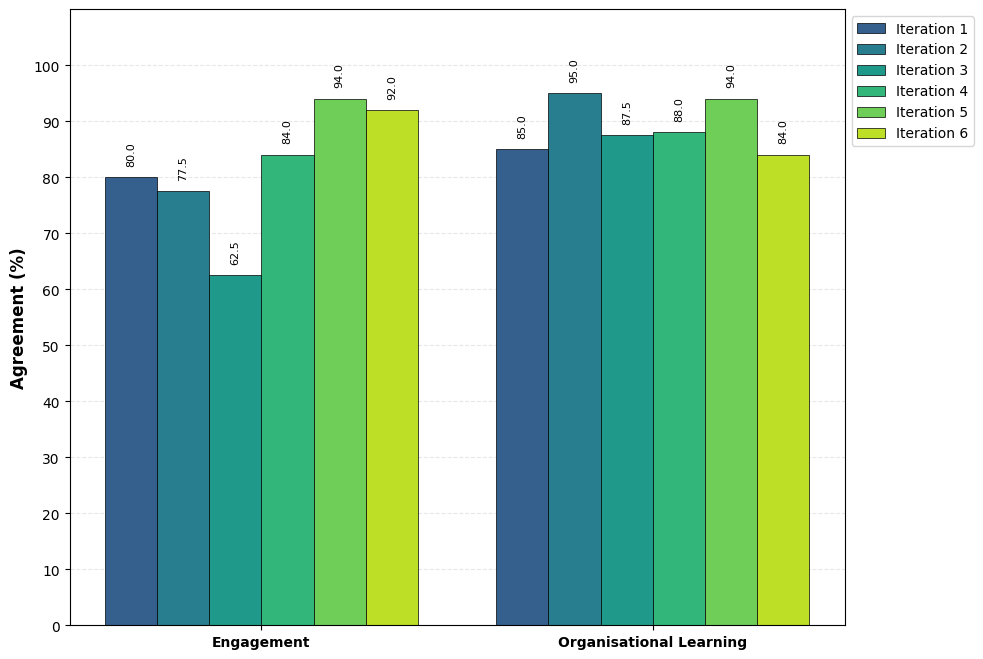

In [79]:
df_agreement = pd.concat([binary_irr[['Iteration','Variable','Agreement_pct']],ordinal_irr[['Iteration','Variable','Agreement_pct']]])
df_agreement = df_agreement.fillna(0)

fig, ax = plot_agreement_by_iteration(
    df_agreement, 
    y_col='Agreement_pct',
    
    variable_order=['engagement', 'organisationalLearning'],
    variable_labels={
        'engagement': 'Engagement',
        'organisationalLearning': 'Organisational Learning',
    },
    figsize = (10, 8), 
    show_ci=False,
    title=None,
    ylabel="Agreement (%)",
    xlabel = 0
    
)
plt.show()

The agreement plot shows a broadly positive trajectory for both engagement and organisationalLearning across the six iterations. Engagement maintained consistently high agreement throughout, with a visible dip in Iteration 3 that recovered fully by Iteration 4. Agreement for organisationalLearning showed greater variability — consistent with its lower and more variable Krippendorff α values — but trended upward across the later iterations.

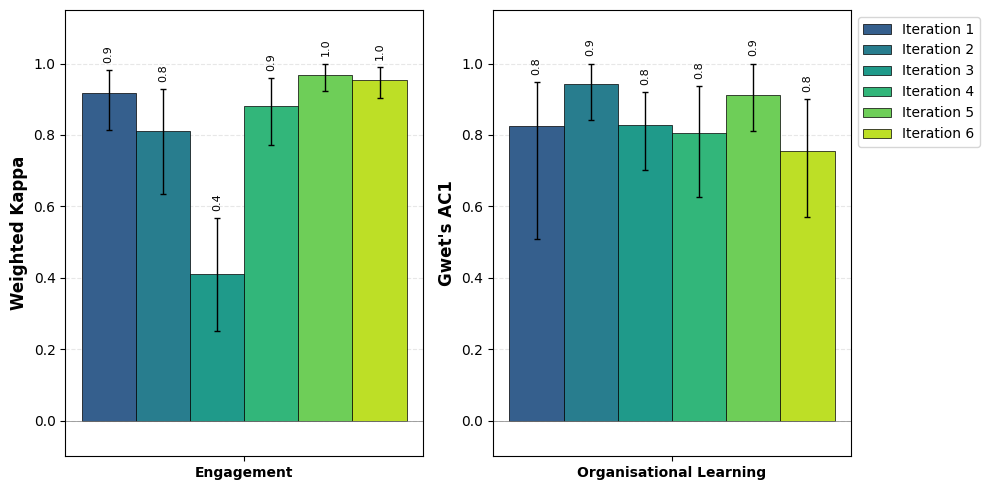

In [80]:
plot_configs = [
    {
        'df': ordinal_irr, 
        'y_col': 'Weighted_kappa',
        'show_ci': True,
        'ci_lower_col': 'Kappa_CI_lower',
        'ci_upper_col': 'Kappa_CI_upper',
        'title': "",
        'variable_labels': {
            'engagement': 'Engagement',
        },
        'ylabel': 'Weighted Kappa',
        'xlabel':None
    },
    {
        'df': binary_irr.fillna(0), 
        'y_col': 'Gwet_AC1', 
        'title': '',
        'ylabel': "Gwet's AC1",
        'show_ci': True,
        'ci_lower_col': 'Gwet_CI_lower',
        'ci_upper_col': 'Gwet_CI_upper',
        'variable_order': ['organisationalLearning'],
        'variable_labels': {
            'organisationalLearning': 'Organisational Learning'
        },
        'xlabel': None
    },

]

fig, axes = create_subplot_figure(
    plot_configs, 
    nrows=1, 
    ncols=2, 
    figsize=(10, 5),
    share_legend=True,  # Shows one legend on the rightmost plot
    suptitle=""
)
plt.show()

The IRR plots show weighted kappa (engagement) and Gwet's AC1 (organisational learning) across pilot iterations, with 95% bootstrap confidence intervals. Confidence intervals are wider in the earlier iterations where coding batch sizes were smaller, and narrow as sample sizes increase. By iterations 5 and 6, reliability estimates for both variables carry comparatively tight confidence intervals, reflecting stable and consistent coding. Weighted kappa for engagement reached excellent levels (≥ 0.80) from Iteration 1 and was maintained throughout, while Gwet's AC1 for organisational learning showed greater variability, but had a generally upward trend.

Print the disagreements across all variables:

(<Figure size 1400x800 with 1 Axes>,
 <Axes: title={'center': 'Percentage of Disagreements Across Variables by Iteration'}, xlabel='Iteration', ylabel='Percentage of Disagreements (%)'>)

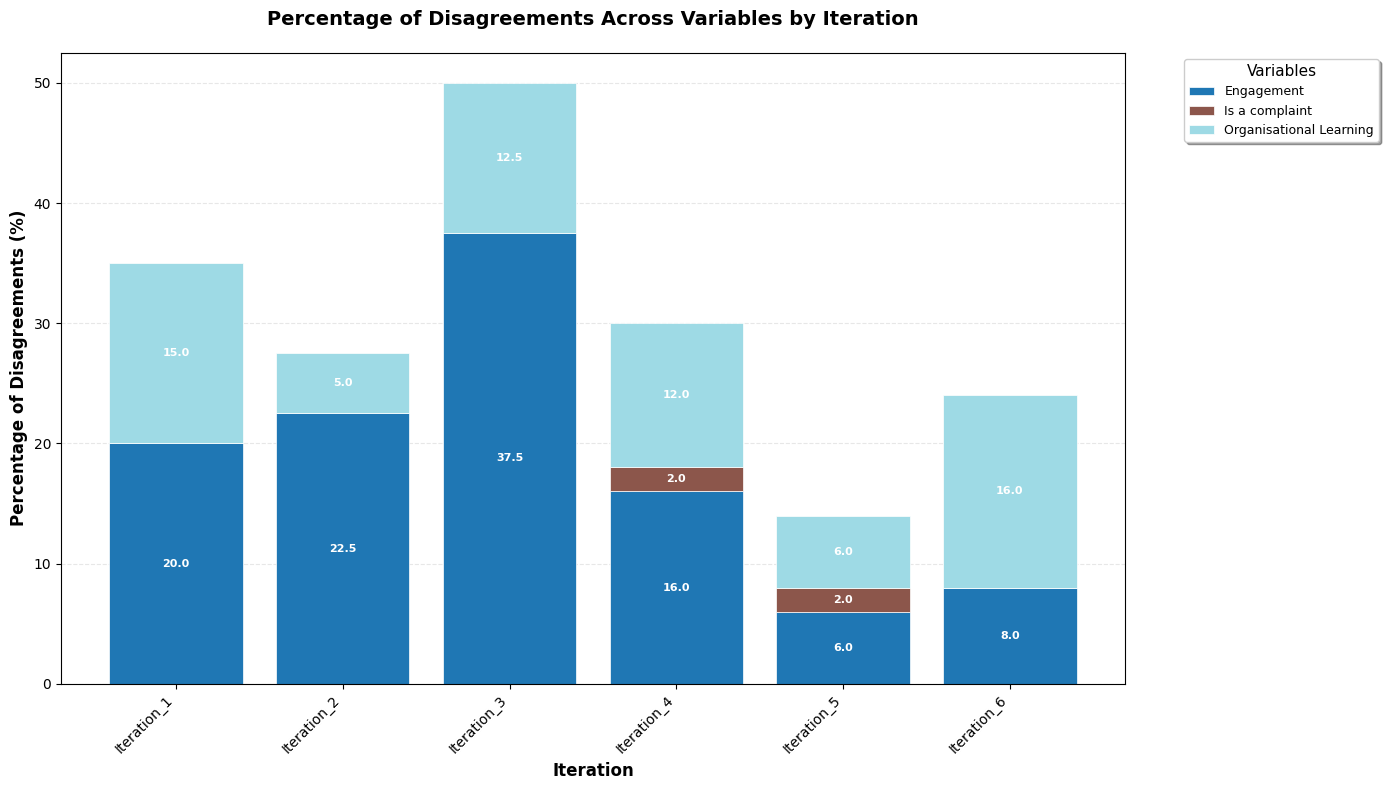

In [81]:

# Create name dictionary for cleaner output
rename_vars = {
    'isComplaint':"Is a complaint",
    'engagement': 'Engagement',
    'organisationalLearning':"Organisational Learning"}

# Specify variable types
var_types = {
    'isComplaint':"nominal",
    'organisationalLearning':"nominal",
    'engagement': 'ordinal',
}

# Get summary by iteration
summary_by_iteration = get_disagreements_summary(
    PilotIterations, 
    rename_vars.keys(),
    var_name_dict=rename_vars,
    var_type_dict=var_types,
    by_iteration=True
)

# Get overall summary (across all iterations)
overall_summary = get_disagreements_summary(
    PilotIterations, 
    rename_vars.keys(),
    var_name_dict=rename_vars,
    var_type_dict=var_types,
    by_iteration=False
)

# Display the results
plot_disagreement_stacked_bar(summary_by_iteration)

The chart shows that is a complaint had consistently low disagreement rates across all iterations. Engagement and organisational learning generated more frequent disagreements, particularly in the earlier iterations, reducing substantially from Iteration 4 onwards.

## 1.2 Inter-rater reliability

Below shows the results of the final iteration of coding (Iteration 7) where coders were provided 400 story-response pairs each, of which 200 were shared amongst them and 200 were unique to the coder. The inter-rater reliability was calculated on the shared 200 and the two coders were not made aware of which story-response pairs were shared to mitigate any biases.

In [82]:

for var in bin_vars:
    c1 = FinalIteration_IRR[f"{var}_C1"]
    c2 = FinalIteration_IRR[f"{var}_C2"]

    # Calculate Krippendorff's alpha with CI
    alpha_result = bootstrap_ci_krippendorff(c1, c2, n_bootstrap=1000, random_state=42)
    
    # Calculate Gwet's AC1 with CI
    ac1_result = bootstrap_ci_gwet_ac1(c1, c2, n_bootstrap=1000, random_state=42)
    
    # Calculate percent agreement
    agreement = percent_agreement(c1, c2)
    
    # Get display name
    display_name = rename_vars.get(var, var)

    print(
        f"{display_name}:\n"
        f"  Krippendorff's α = {alpha_result['alpha']:.3f} "
        f"[95% CI: {alpha_result['CI_lower']:.3f}, {alpha_result['CI_upper']:.3f}]\n"
        f"  Gwet's AC1 = {ac1_result['AC1']:.3f} "
        f"[95% CI: {ac1_result['CI_lower']:.3f}, {ac1_result['CI_upper']:.3f}]\n"
        f"  Agreement = {agreement}%\n"
    )


Is a complaint:
  Krippendorff's α = 0.990 [95% CI: 0.969, 1.000]
  Gwet's AC1 = 0.990 [95% CI: 0.970, 1.000]
  Agreement = 99.5%

Organisational Learning:
  Krippendorff's α = 0.598 [95% CI: 0.423, 0.740]
  Gwet's AC1 = 0.839 [95% CI: 0.767, 0.903]
  Agreement = 88.5%



Reliability for is a complaint in the final coding iteration was excellent (α = 0.990). For organisational learning, Reliability was acceptable (α = 0.598; AC1 = 0.839), the discrepancy between α and Gwet's AC1 reflects the low base rate of organisational learning responses in the coding sample.

In [83]:

ordinal_vars = ['engagement']

ordinal_ranges = {
    'engagement': [0, 1, 2],  
}

for var in ordinal_vars:
    c1 = FinalIteration_IRR[f"{var}_C1"]
    c2 = FinalIteration_IRR[f"{var}_C2"]
    
    # Calculate ICC
    res = icc_3k_ordinal(FinalIteration_IRR, var)
    
    # Get labels for this variable (if defined in ordinal_ranges)
    var_labels = ordinal_ranges.get(var, None)
    
    # Calculate Weighted Kappa with CI (using quadratic weights for ordinal data)
    kappa_result = bootstrap_ci_weighted_kappa(
        c1, c2,
        weights='quadratic',  # Use quadratic weights for ordinal data
        n_bootstrap=1000,
        confidence=0.95,
        random_state=42,
        labels=var_labels  # Pass the full range if available
    )
    
    # Calculate percent agreement
    agreement = percent_agreement(c1, c2)
    
    # Get display name
    display_name = rename_vars.get(var, var)

    print(
        f"{display_name}:\n"
        f"  ICC(3,k) = {res['ICC3k']:.3f} "
        f"[95% CI: {res['CI95%'][0]:.3f}, {res['CI95%'][1]:.3f}], "
        f"p = {res['pval']:.3g}\n"
        f"  Weighted Kappa (quadratic) = {kappa_result['kappa']:.3f} "
        f"[95% CI: {kappa_result['CI_lower']:.3f}, {kappa_result['CI_upper']:.3f}]\n"
        f"  Agreement = {agreement:.1f}%\n"
    )

Engagement:
  ICC(3,k) = 0.949 [95% CI: 0.930, 0.960], p = 3.65e-75
  Weighted Kappa (quadratic) = 0.900 [95% CI: 0.859, 0.933]
  Agreement = 86.0%



Reliability for engagement in the final coding iteration was excellent (ICC(3,k) = 0.949; κ = 0.900).

In [84]:
overall_summary = get_disagreements_summary(
    FinalIteration_IRR, 
    rename_vars.keys(),
    var_name_dict=rename_vars,
    var_type_dict=var_types,
    by_iteration=False
)

In [85]:
overall_summary

,Variable,Variable_Type,N_Coded,N_Disagreements,Pct_Disagreements
0,Is a complaint,nominal,200,1,0.5
1,Engagement,ordinal,200,28,14.0
2,Organisational Learning,nominal,200,23,11.5


In the final coding iteration, is a complaint had the lowest disagreement rate (0.5%; 1 of 200 cases), while engagement (14.0%; 28/200) and organisational learning (11.5%; 23/200) generated more disagreements. The higher rates for the latter two variables are consistent with the more complex conceptualisations of the variables.

## 1.3 Validity checks

To supplement the quantitative inter-rater reliability statistics, a qualitative examination of the disagreements between coders was conducted. Cases where coders disagreed were reviewed to identify recurring themes and ambiguities in the coding scheme.

In [86]:
disagreements_df = pd.read_csv("final_data/disagreements.csv")

In [45]:
def print_disagreements_by_id(story_ids, n=None):
    """
    Print disagreement cases from disagreements_df.
    """
    subset = disagreements_df[disagreements_df["story_id"].isin(story_ids)].copy()
    if n is not None:
        subset = subset.head(n)

    delimiter = "\n" + "=" * 60 + "\n"

    entries = []
    for _, row in subset.iterrows():
        title = row['title_text'].replace('\n', ' ').replace('\r', '')
        story = row['story_text'].replace('\n', ' ').replace('\r', '')
        response = row['response_text'].replace('\n', ' ').replace('\r', '')
        entry = f"Title: {title}\nStory: {story}\n\nResponse: {response}"
        entries.append(entry)
    print(delimiter.join(entries).replace("rn", ""))
    
    


### 1.3.1 Engagement disagreements

We identified two patterns in engagement disagreements. First, coders found it difficult to code when the story was both positive and negative and the response only engaged with the positive aspects of the story. Second, coders found it difficult to agree on cases where providers provide surface level responses; they engage with the problem's topic, but not the substantive issues raised.

In [57]:
positive_engagement = [2,32,42]
print_disagreements_by_id(positive_engagement, n=4)

Title: Great staff but I would like more information
Story: I have an inverted nipple which leaks a matter substance. The pain 5 weeks ago in the nipple was very severe, but eventually the pain spread around the breast and undeeath the arm. I have had this problem before in 2009  but now I find some pain in the other breast and arm.   My consultant was Mr Arora, a lovely gentleman with a caring attitude. But I would like to know the reason for beast mattering at 67 years of age and the cause of the pain.  Although mammogram was clear it still bothers me. Could these symptoms lead to more severe problems in the future?  I must state once again the care and attention both from Mr Arora and staff are excellent

Response: Thanks for this posting.  I am very pleased you are happy with the service you received at Tameside Hospital, in particular the care you received from Mr. Arora.  I will  make sure he is aware of your kind comments.  I am sorry but is not possible to answer your clinical 

In [56]:
#full_list = [7, 8, 10, 12, 16, 21, 22, 23, 28, 29, 30, 35, 40, 42, 43]
partial_engagement = [7, 10, 16, 21]
print_disagreements_by_id(partial_engagement, n=4)

Title: Terrible
Story: I was treat very badly. The whole experience left me feeling even more emotionally and mentally vulnerable. I was not given any of my medication and was basically left in a room for three days to weep alone

Response: Thank you for your feedback conceing your stay at West Park Hospital. We are very sorry to hear that you found the experience to be terrible and feel that mental health services in Darlington are a waste of time. We aim to provide excellent services that exceed patient expectations therefore take all feedback very seriously and would like to reassure you that any conces raised by the public regarding services or  the attitude / behaviour of staff are fully investigated. It is important that we do this so that we can lea lessons in order to continuously improve our services. We would be happy to meet with you and discuss your conces and reflections further. If this is something you would like to do, please contact Corinne Aspel, Senior Nurse Patient 

### 1.3.2 Organisational Learning disagreements

We identified three patterns in organisational learning disagreements. First, coders found it difficult to assign whether a promise to investigate counted as organisational learning. Second, coders found it difficult to score when organisations made ambiguous references to change. Finally, coders found it difficult to code when the organisation invited patients to come in and help with changing the organisation.

In [60]:
promise_to_investigate = [10,17,18,31,37,43]
print_disagreements_by_id(promise_to_investigate, n=4)

Title: Do not use this surgery!!
Story: Do not use this surgery! Unsympathetic, unempathetic doctors with no people skills! Little sympathy towards patients who are dealing with very sad issues. Aggressive and confrontational doctors who seem to be more interested in trying to belittle you and make your problem seem a much smaller issue than it actually is. Have tried leaving in depth review 3 times, but sadly all have been rejected. Sad because the general public deserve the right to know what sort of service they would receive if they joined this surgery. Do not use this surgery!!

Response: Dear user I am sorry that you feel you have had a bad experience with a doctor here. We would not wish this for any of our patients. Please could you contact me at the surgery, either by phone on 01225 427402 or via email helen.harris1@nhs.net, so that I can look into this for you and investigate why you feel you had such a bad experience. From the national patient survey, our patients rated us i

In [63]:
vague_potential_change = [4,7,32,34]
print_disagreements_by_id(vague_potential_change, n=3)

Title: Long wait for an appointment however the treatment was very good
Story: My story in three stages 1) GP experience very good with a positive diagnosis 2) A wait of nearly 3 months before an appointment for treatment (very poor) 3) Once an appointment had been secured, treatment was very good and is currently on-going

Response: Dear Reader166Thank you for sharing your comments relating to your recent experience.I am sorry that your wait for an appointment was longer than expected.Unfortunately, the appointment capacity at hospitals is outside TRAQS control as we can only offer appointments when they have been released for booking by the hospital.TRAQS will always offer a patient the first available appointment but we do realise that not everyone can travel further for an earlier appointment.I am pleased to note that the treatment you received was very good and that your treatment is on going.We wish you well for the future and would like to thank you for taking the time to share 

In [72]:
collaborative_engagement = [32, 36, 24] # also 34
print_disagreements_by_id(collaborative_engagement, n=3)

Title: poor service from reception
Story: No problem with the doctors or nurses. The reception staff are  abrupt and rude, and make it impossible to see or speak to a doctor. Deciding whether your condition is bad enough to bother the doctor with. Despite the fact they have no medical training. They have reduced me to tears on more than one occasion.

Response: Sorry that your experience has not been a positive one. We do ask our receptionists to gather information about the reasons for patients calls and this is explained on our phone message before you speak to a receptionist. If you would like us to investigate this matter further, please contact the surgery directly.
Title: Very helpful.
Story: Called for a pharmacist appointment....was called back by a pharmacist within 5 minutes! Fantastic  Only downside is that thee can be long waits for the calls to be answered....otherwise, great service!

Response: Dear Patient Thank you for your positive feedback. Given the circumstances and

In [73]:
general_improvement = [5,9,27]
print_disagreements_by_id(general_improvement, n=3)

Title: Outpatients Appointment.
Story: I have MS and have mobility problems.On 18/5 I had an outpatients appointment and I was dismayed to find that due to reconstruction access was via the main entrance meaning I had to walk down a very long corridor to reach my appointment.It was a long painful struggle,no seating had been provided down the corridor to provide rest opportunities for less able patients.

Response: Really sorry to hear about your experience whilst carrying out these essential works to improve our Main Outpatients Department for everyone. If you have any other appointments at the hospital you can request for a wheelchair at the Main Entrance to take you to Outpatients.
Title: Ver poor
Story: Been on phone for 15 mins tring to get threw, Whe you do get threw you have to ring up again to try and get you in, Poor service some Doctors do not listen to your problems starting to get fed up with them.

Response: We are sorry that you have had a wait before getting through this

# 2. Classifier development

The gold-standard dataset created through manual coding was subsequently used to develop a text classifier for engagement and organisational learning. Below is the variable mapping (expressed as Pydantic models) and three corresponding prompts used with GPT models. These are the final prompts created after a process of iterative development. Note that engagement was reduced to a binary variable during the development of the prompt. The full dataset was coded using these prompts on GPT-5-mini (Low Reasoning). Instructions for passing to the OpenAI API are provided below for demonstration purposes and replication. 

In [38]:
# Prompt 1 model - identifies if complaint, sent to all stories without responses
class Prompt1Model(BaseModel):
    # Is a complaint
    isComplaint: int = Field(description="Is this a complaint? 0 for No, 1 for Yes")
    isComplaintReasoning: str = Field(description="Reason for complaint classification.")
    isComplaintQuote: str = Field(description="Indicative quote for complaint classification.")
    
# Prompt 2 model - identifies engagement and organisational learning. All complaints identified from Prompt 1 sent with responses included.
class Prompt2Model(BaseModel):
    # To what degree does the response engage with the complaint
    engagementResponse: int = Field(description="Does the response engage with the issues in the complaint? 0 for No, 1 for Yes")
    engagementResponseReasoning: str = Field(description="Reason for engagement response classification.")
    engagementResponseQuote: str = Field(description="Indicative quote for engagement response  classification.")
    # Does the response provide evidence of organisational learning
    organisationalLearningResponse: int = Field(description="Does the response provide evidence of organisational learning? 0 for No, 1 for Yes")
    organisationalLearningResponseReasoning: str = Field(description="Reason for organisational learning in response classification.")
    organisationalLearningResponseQuote: str = Field(description="Indicative quote for organisational learning in response classification.")


In [39]:

# SYSTEM PROMPT FOR THE 1ST PROMPT
System1 = """You are an organisational psychologist tasked with analysing stories written about a UK healthcare providers.
General terminology:
Healthcare provider = The organisation who the story is directed towards
Storyteller = The person relaying the story (e.g., patient, loved one, friend)
Story = The story about a healthcare provider
Complaint = A story that provides negative feedback about the healthcare provider"""


# PROMPT 1 FOR IDENTIFYING IF A COMPLAINT
Prompt1 = """Below is a story written by a person about their experiences with a healthcare provider.
Your task is to identify whether the story is a complaint by indicating whether the story reports ANY patient harm caused by an error, failure, or violation by the healthcare provider.
The harm must have been caused by a health service mishap or actions taken by healthcare workers.

-
STORY:
{story_text}
-

Please answer the following questions:

First, is this story a complaint?
Scoring scheme: 
[0] - "No"
[1] - "Yes"

If relevant, please include a short (one sentence) quote from the raw text that supports your rating.
Please justify your ratings for each question in ONE SENTENCE."""


# SYSTEM PROMPT FOR THE 1ST AND 2ND PROMPT
System2 = """You are an organisational psychologist tasked with analysing complaints written about a UK healthcare providers.
General terminology:
Healthcare provider = The organisation who the story is directed towards
Storyteller = The person relaying the story (e.g., patient, loved one, friend)
Responder = The person replying to the story (e.g., complaints handler)
Story = The story about a healthcare provider
Complaint = A story that provides negative feedback about the healthcare provider
Issue = Problems raised within a complaint caused by a health service mishap or actions taken by healthcare workers
Response = The healthcare provider's response to the story"""

# PROMPT 2 FOR IDENTIFYING RESPONSE VARIABLES
Prompt2 = """Below is a complaint about a healthcare provider and the provider's response to the complaint.
Your task is to assess the quality and degree of engagement in the response.

-
COMPLAINT:
{complaint_text}
RESPONSE:
{response_text}
-

Please answer the following questions:

First, does the response engage with the issues raised in the complaint?
Scoring scheme:
[0] "No" - Response provides a rudimentary or brief paraphrasing of one or more issues and does not mention any of the issues raised, or is a generic / group response.
[1] "Yes" – Response demonstrates beyond rudimentary engagement with one or more issues.

Second, does the response report any evidence of organisational learning?
Scoring scheme:
[0] "No learning" – Does not report any current or future measures to prevent issue(s) occurring in future.
[1] "Learning evidenced" - Reports current or future measures to prevent issue(s) occurring in future.

If relevant, please include a short (one sentence) quote from the raw text that supports each of your ratings.
Please justify your ratings for each question in ONE SENTENCE."""

In [44]:
class classifier:
    def __init__(self, client, model="gpt-5-mini", reasoning_effort="low"):
        self.client = client
        self.model = model
        self.reasoning_effort = reasoning_effort

    def general_classifier(self, messages, response_model):
        response = self.client.beta.chat.completions.parse(
                        model=self.model,
                        messages=messages,
                        reasoning_effort=self.reasoning_effort,
                        response_format=response_model
                    )
        return response.choices[0].message.parsed

    def Prompt1_classify(self, story_text):
        messages = [
                {"role": "system", "content": System1},
                {"role": "user", "content": Prompt1.format(story_text = story_text)}
            ]
        response = self. general_classifier(messages, Prompt1Model)
        return response


    def Prompt2_classify(self, complaint_text, response_text):
        messages = [
                {"role": "system", "content": System2},
                {"role": "user", "content": Prompt2.format(complaint_text = complaint_text, response_text = response_text)}
            ]
        response = self. general_classifier(messages, Prompt2Model)
        return response
    
    def demonstration_classifier(self, complaint_text, response_text):
        response1 = self.Prompt1_classify(complaint_text)
        response1 = response1.model_dump()
        response3 = self.Prompt2_classify(complaint_text, response_text)
        response3 = response3.model_dump()
        
        return f"""-- PROMPT 1 RESPONSES: --
        
Q1: Is this story a complaint?
Response: {response1["isComplaint"]}
Reasoning: {response1["isComplaintReasoning"]}
Supporting quote: {response1["isComplaintQuote"]}

-- PROMPT 2 RESPONSES: -- 

Q2: Does the response engage with the issues raised in the complaint? (1=Yes)
Response: {response3["engagementResponse"]}
Reasoning: {response3["engagementResponseReasoning"]}
Supporting quote: {response3["engagementResponseQuote"]}

Q3: Does the response report any evidence of organisational learning? (1=Yes)
Response: {response3["organisationalLearningResponse"]}
Reasoning: {response3["organisationalLearningResponseReasoning"]}
Supporting quote: {response3["organisationalLearningResponseQuote"]}
"""

The classifier can be used on any story-response pair to gain a classification. Below is an example from the dataset (https://www.careopinion.org.uk/169864) for demonstration purposes. An OpenAI API key is required to use the classifier. 

In [41]:
# Link to original story
example_story = """My husband was admitted as an emergency from A&E and then taken to the Adult critical care unit where he died.
The circumstances are questionable and the behaviour of some of the senior medical staff was disgraceful, never want to set foot in this hospital again"""

example_response = """We are extremely sorry that you have been left so distressed following your husband's sad death at our hospital. 
We are also very sorry for the significant delay in responding to your posting on the NHS Choices website. 
It is difficult to respond to your concerns fully due to the anonymity of the the website. 
We would be more than happy to meet with you to discuss any concerns you may have and offer support. 
If you contact our Patient Advice and Liaison Service (PALS) on 0161 276 8686 or by emailing pals@cmft.nhs.uk they will be able to arrange this for you.
The Patient Experience Team
Central Manchester University Hospitals, NHS Foundation Trust
"""

In [46]:
OIAK = "-your-OpenAI-API-key-here"

client = OpenAI(
    api_key=OIAK,
)

In [45]:
gptClassifier = classifier(client = client)
example_output = gptClassifier.demonstration_classifier(complaint_text = example_story, response_text = example_response)
print(example_output)

-- PROMPT 1 RESPONSES: --

Q1: Is this story a complaint?
Response: 1
Reasoning: The story reports the patient's death following admission and criticises the conduct of senior medical staff, implying harm related to the healthcare provider's actions or failures.
Supporting quote: "The circumstances are questionable and the behaviour of some of the senior medical staff was disgraceful"

-- PROMPT 2 RESPONSES: -- 

Q2: Does the response engage with the issues raised in the complaint? (1=Yes)
Response: 1
Reasoning: The response acknowledges the bereavement and the concerns, apologises for the delay, and offers a specific route (PALS) and meeting to discuss the issues, showing active engagement beyond a generic statement.
Supporting quote: We would be more than happy to meet with you to discuss any concerns you may have and offer support.

Q3: Does the response report any evidence of organisational learning? (1=Yes)
Response: 0
Reasoning: The response contains no statement of investigation

## 2.1 Training and prompt development

Below details the results of the prompt adjustments for fine-tuning the LLM classifier to the manually coded data. We used a 30/70 train-test split of the data, meaning that 70% of the data was witheld from prompt development and only used to assess the final prompt.

In [10]:
train_results = pd.read_csv("final_data/train_results.csv")
test_results = pd.read_csv("final_data/test_results.csv")

train_size = len(train_results)
test_size = len(test_results)
total_size = train_size + test_size
train_pct = 100*(train_size / total_size)
test_pct = 100*(test_size / total_size)

print(f"""
Total number of story-response pairs = {total_size}
Train size = {train_size}({train_pct:.2f}%)
Test size = {test_size}({test_pct:.2f}%)
""")


Total number of story-response pairs = 600
Train size = 180(30.00%)
Test size = 420(70.00%)



The prompt development happened over eight iterations of adjustments. This involved running the prompt over the training data, examining the evaluation metrics and misclassifications, and adjusting the prompts accordingly. After the fourth iteration, we noted that the classifier was good at identifying the presence of engagement, but not good at distinguishing between different levels of the variable. We therefore adjusted the prompt to identify engagement as a binary variable, requiring us to create binary variables from the originally manually coded data:

In [88]:
train_results["engagement_trueBin"] = train_results.engagement_true.apply(lambda x: 1 if x > 1 else 0)

In [19]:


def camel_case_split(text):
    """Split camelCase text into separate words"""
    return re.sub('([a-z])([A-Z])', r'\1 \2', text)

train_complaints = train_results[train_results.isComplaint_true == 1].copy()

# Define binary classifier configurations
binary_configs = [
    ('isComplaint', train_results, 3),
    ('organisationalLearning', train_complaints, 8),
]

# Define special binary cases
special_binary = [
    ('engagement', train_complaints, 'trueBin', [4,5,6,7,8]),
]

# Define ordinal classifier configurations
ordinal_configs = [
    ('engagement', train_complaints, 3),
]

# Generate binary results
binary_results = []
for field, data, iterations in binary_configs:
    # Split camelCase and clean up
    name = camel_case_split(field)
    name = name.replace('', '').replace('Request', ' Request').replace('Learning', ' Learning')
    name = ' '.join(word.capitalize() for word in name.split())
    
    # Handle special cases
    if field == "organisationalLearning":
        name = "Organisational Learning"
        
    for i in range(1, iterations + 1):
        binary_results.append(
            evaluate_binary_classifier(
                data[f'{field}_true'], 
                data[f'{field}_R{i}'], 
                name=name, 
                iteration=i
            )
        )

# Add special binary cases
for field, data, suffix, iterations in special_binary:
    name = ' '.join(word.capitalize() for word in field.split())
    
    for i in iterations:
        binary_results.append(
            evaluate_binary_classifier(
                data[f'{field}_{suffix}'], 
                data[f'{field}_R{i}'], 
                name=name, 
                iteration=i
            )
        )

# Generate ordinal results
ord_results = []
for field, data, iterations in ordinal_configs:
    name = ' '.join(word.capitalize() for word in name.split())
    
    for i in range(1, iterations + 1):
        ord_results.append(
            evaluate_ordinal_classifier(
                data[f'{field}_true'], 
                data[f'{field}_R{i}'], 
                name=name, 
                iteration=i
            )
        )

train_bin_results = pd.DataFrame(binary_results).round(2)
train_ord_results = pd.DataFrame(ord_results).round(2)

We can observe below from the results of the prompt iterations how the accuracy jumps from 0.67 to 0.84 for engagement response after switching to a binary classification and from 0.67 to 0.73 for intervention response. This justifies our changes to the prompt. 

Binary results across iterations:

In [20]:
train_bin_results

,name,iteration,n,accuracy,precision,recall,f1,mcc,tp,tn,fp,fn
0,Is Complaint,1,180,0.94,1.00,0.88,0.94,0.89,72,98,0,10
1,Is Complaint,2,180,0.93,1.00,0.85,0.92,0.87,70,98,0,12
2,Is Complaint,3,180,0.94,1.00,0.87,0.93,0.88,71,98,0,11
3,Organisational Learning,1,82,0.79,0.74,0.61,0.67,0.52,17,48,6,11
4,Organisational Learning,2,82,0.80,0.77,0.61,0.68,0.55,17,49,5,11
5,Organisational Learning,3,82,0.83,0.85,0.61,0.71,0.61,17,51,3,11
6,Organisational Learning,4,82,0.82,0.88,0.54,0.67,0.58,15,52,2,13
7,Organisational Learning,5,82,0.80,0.88,0.50,0.64,0.55,14,52,2,14
8,Organisational Learning,6,82,0.80,0.75,0.64,0.69,0.55,18,48,6,10
9,Organisational Learning,7,82,0.84,0.74,0.82,0.78,0.66,23,46,8,5


Ordinal results across iterations:

In [21]:
train_ord_results

,name,iteration,n,classes,accuracy,mae,within_1_acc,kappa_linear,spearman_r,spearman_p,kendall_tau,kendall_p
0,Engagement,1,82,"[0, 1, 2]",0.50,0.51,0.99,0.42,0.64,0.0,0.60,0.0
1,Engagement,2,82,"[0, 1, 2]",0.65,0.37,0.99,0.58,0.70,0.0,0.65,0.0
2,Engagement,3,82,"[0, 1, 2]",0.56,0.46,0.98,0.50,0.73,0.0,0.68,0.0


Plot of the accuracy for engagement and organisational learning for all iterations.

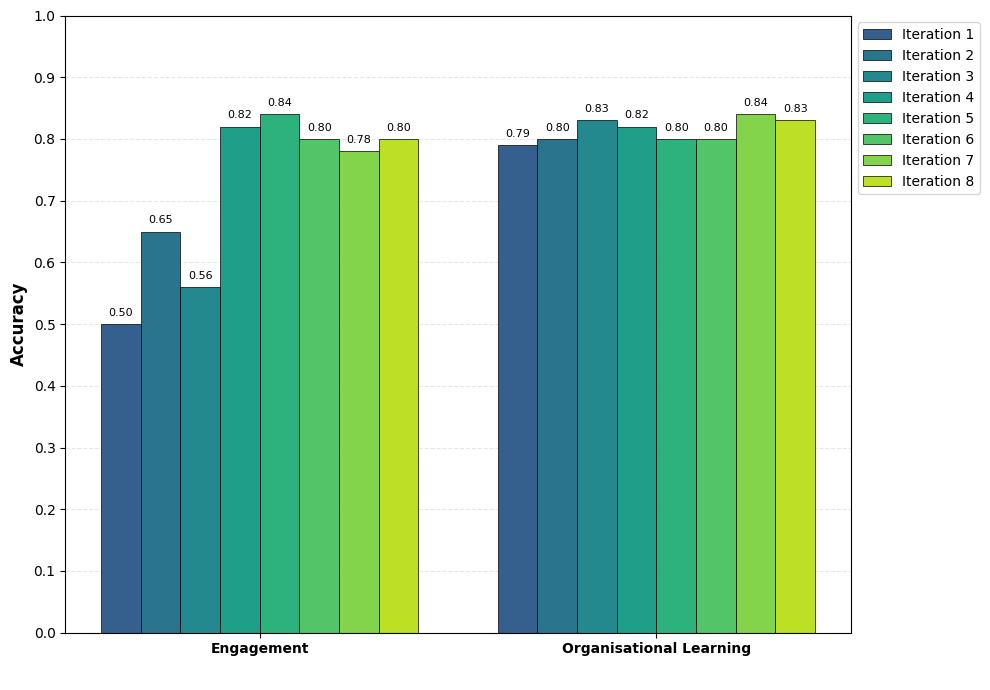

In [22]:

# Create shared dataframe from results
train_bin_acc = train_bin_results[["name", "iteration", "accuracy"]].reset_index().copy()
train_ord_acc = train_ord_results[["name", "iteration", "accuracy"]].reset_index().copy()
train_accuracy = pd.concat([train_bin_acc, train_ord_acc])
# Variable ordering
name_order = ['Engagement', 'Organisational Learning']
# Plot the results
fig, ax = plot_grouped_accuracy(train_accuracy, figsize=(10, 7), 
                                name_order = name_order, 
                                show_values=True)
plt.show()


Plot the F1 score for the final five iterations after engagement switched to binary variable:

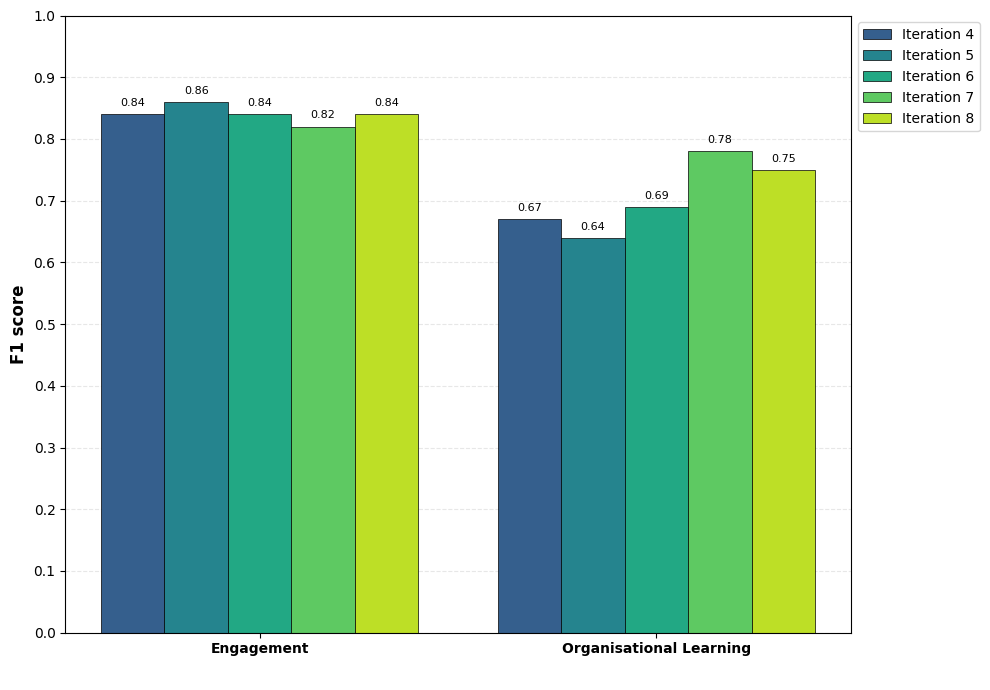

In [23]:
# Create shared dataframe from results\
train_bin_acc2 = train_bin_results[["name", "iteration", "f1"]].reset_index().copy()
train_bin_acc2 = train_bin_acc2[train_bin_acc2['iteration'] > 3]
# Variable ordering
name_order = [ 'Engagement', 'Organisational Learning']
# Plot the results
fig, ax = plot_grouped_accuracy(train_bin_acc2, figsize=(10, 7), 
                                name_order = name_order, 
                                show_values=True, metric ='f1', ylabel ='F1 score')
plt.show()

## 2.2 Evaluation metrics

We used the prompt from the 7th iteration to assess the classifier on the test data. The prompts were not developed on the test data and therefore we can be assured of an unbiased evaluation. We employed the prompts on three models to determine which would be best for coding the full dataset: GPT-5-mini (low reasoning), GPT-5-mini (high reasoning), GPT-5 (high reasoning).

In [24]:
test_results = pd.read_csv("final_data/test_results.csv")

In [25]:
test_complaints = test_results[test_results.isComplaint_true == 1]
# Define model versions
model_versions = [
    ('miniLow', 'GPT-5-mini (low)'),
    ('miniHigh', 'GPT-5-mini (high)'),
    ('5High', 'GPT-5 (high)')
]

# Define binary classifier configurations
binary_configs = [
    ('isComplaint', test_results, 'Is Complaint'),
    ('engagement', test_complaints, 'Engagement'),
    ('organisationalLearning', test_complaints, 'Organisational Learning'),
]

# Generate binary results
binary_results_test = []
for field, data, name in binary_configs:
    for version_suffix, version_name in model_versions:
        binary_results_test.append(
            evaluate_binary_classifier(
                data[f'{field}_true'],
                data[f'gpt_{field}_{version_suffix}'],
                name=name,
                iteration=version_name
            )
        )


test_bin_results = pd.DataFrame(binary_results_test).round(2)

In [26]:
test_bin_results

,name,iteration,n,accuracy,precision,recall,f1,mcc,tp,tn,fp,fn
0,Is Complaint,GPT-5-mini (low),420,0.94,0.98,0.89,0.93,0.88,171,224,3,22
1,Is Complaint,GPT-5-mini (high),420,0.94,0.99,0.87,0.93,0.88,168,226,1,25
2,Is Complaint,GPT-5 (high),420,0.96,0.99,0.92,0.95,0.92,178,225,2,15
3,Engagement,GPT-5-mini (low),193,0.82,0.78,0.97,0.86,0.64,111,47,32,3
4,Engagement,GPT-5-mini (high),193,0.82,0.78,0.97,0.86,0.64,111,47,32,3
5,Engagement,GPT-5 (high),193,0.89,0.93,0.88,0.90,0.78,100,72,7,14
6,Organisational Learning,GPT-5-mini (low),193,0.81,0.74,0.66,0.70,0.56,43,113,15,22
7,Organisational Learning,GPT-5-mini (high),193,0.80,0.75,0.62,0.68,0.54,40,115,13,25
8,Organisational Learning,GPT-5 (high),193,0.79,0.86,0.46,0.60,0.52,30,123,5,35


On the held-out test set, accuracy for is a complaint was high and consistent across model versions (GPT-5-mini low reasoning: 0.94; GPT-5-mini high reasoning: 0.94; GPT-5 high reasoning: 0.96). For engagement, GPT-5 (high reasoning) outperformed the mini variants (accuracy: 0.89 vs. 0.82) and achieved the best F1 score (0.90). For organisational learning, all models performed similarly (accuracy = 0.81), with GPT-5-mini (low reasoning) achieving the highest F1 (0.70).

Print the best model for our variables:

In [28]:
for name, group in test_bin_results.groupby('name'):
    best_row = group.loc[group['f1'].idxmax()]
    print(f"Variable: {name}")
    print(f"  Best Model: {best_row['iteration']}")
    print(f"  F1 Score: {best_row['f1']}")
    print()


Variable: Engagement
  Best Model: GPT-5 (high)
  F1 Score: 0.9

Variable: Is Complaint
  Best Model: GPT-5 (high)
  F1 Score: 0.95

Variable: Organisational Learning
  Best Model: GPT-5-mini (low)
  F1 Score: 0.7



Below performs a significance test to compare the classifiers to determine whether one is better to use than an other. We use a Friedman's test to assess if there is any difference between the three classifiers and post-hoc wilcoxon tests to test pairwise differences.

In [29]:
results = compare_classifiers_mixed_variables(
    df=test_results.drop(["story_id","title_text","story_text","response_text"], axis=1),
    classifier_names=['miniLow', 'miniHigh', '5High'],
    var_config='auto',
    metric='accuracy'
)


Mean accuracy across all variables:
classifier
5High       0.8812
miniLow     0.8558
miniHigh    0.8533
dtype: float64

=== Friedman Test (across all 3 variables) ===
Chi-squared statistic: 1.2727
p-value: 0.5292
Result: No significant difference found among classifiers (p >= 0.05)

=== Pairwise Comparisons (Wilcoxon signed-rank test) ===

miniLow vs miniHigh:
  Mean difference: 0.0025
  p-value: 0.5000
  Result: No significant difference

miniLow vs 5High:
  Mean difference: -0.0253
  p-value: 0.5000
  Result: No significant difference

miniHigh vs 5High:
  Mean difference: -0.0279
  p-value: 0.5000
  Result: No significant difference

=== With Bonferroni Correction (α = 0.0167) ===


Perform the test again but using the F1 scores:

In [30]:
results = compare_classifiers_mixed_variables(
    df=test_results.drop(["story_id","title_text","story_text","response_text"], axis=1),
    classifier_names=['miniLow', 'miniHigh', '5High'],
    var_config='auto',
    metric='f1'
)


Mean f1 across all variables:
classifier
miniLow     0.8316
miniHigh    0.8233
5High       0.8198
dtype: float64

=== Friedman Test (across all 3 variables) ===
Chi-squared statistic: 1.2727
p-value: 0.5292
Result: No significant difference found among classifiers (p >= 0.05)

=== Pairwise Comparisons (Wilcoxon signed-rank test) ===

miniLow vs miniHigh:
  Mean difference: 0.0083
  p-value: 0.5000
  Result: No significant difference

miniLow vs 5High:
  Mean difference: 0.0118
  p-value: 1.0000
  Result: No significant difference

miniHigh vs 5High:
  Mean difference: 0.0035
  p-value: 1.0000
  Result: No significant difference

=== With Bonferroni Correction (α = 0.0167) ===


The Friedman test found no significant difference in classification accuracy across the three model versions (χ² = 1.27, p = .529). Pairwise Wilcoxon signed-rank tests confirmed no significant pairwise differences (all p ≥ .50). When repeated using F1 scores, the same result was obtained (χ² = 1.27, p = .529), with mean F1 score marginally favouring GPT-5-mini (low reasoning: 0.832). Given the absence of any statistically significant performance difference, we selected GPT-5-mini with low reasoning for coding the full dataset, as it is the most cost-efficient option without sacrificing classification performance.

## 2.3 Validity checks

This section assesses the validity of the classifier. We begin by examining misclassification examples from the test set to understand where the classifier errs. We then load the full dataset and aggregate to the trust-year level to produce descriptive statistics and Spearman correlation tables.

### 2.3.1 Analysing misclassifications

In [11]:
tdf = test_results.copy()
tdf = tdf.dropna(subset=[
    "gpt_engagement_miniLow", "gpt_organisationalLearning_miniLow",
    "engagement_true", "organisationalLearning_true",
])
 
# ── Identify misclassification types ──
tdf["eng_error"] = tdf["engagement_true"] != tdf["gpt_engagement_miniLow"]
tdf["org_error"] = tdf["organisationalLearning_true"] != tdf["gpt_organisationalLearning_miniLow"]
 
eng_fp = tdf[tdf["eng_error"] & (tdf["gpt_engagement_miniLow"] == 1)]
eng_fn = tdf[tdf["eng_error"] & (tdf["gpt_engagement_miniLow"] == 0)]
org_fp = tdf[tdf["org_error"] & (tdf["gpt_organisationalLearning_miniLow"] == 1)]
org_fn = tdf[tdf["org_error"] & (tdf["gpt_organisationalLearning_miniLow"] == 0)]
both   = tdf[tdf["eng_error"] & tdf["org_error"]]
 
# ── Error landscape table ──
landscape = pd.DataFrame([
    {"Error Type": "Engagement FP",        "Count": len(eng_fp), "Direction": "GPT=1, True=0"},
    {"Error Type": "Engagement FN",        "Count": len(eng_fn), "Direction": "GPT=0, True=1"},
    {"Error Type": "Org Learning FP",      "Count": len(org_fp), "Direction": "GPT=1, True=0"},
    {"Error Type": "Org Learning FN",      "Count": len(org_fn), "Direction": "GPT=0, True=1"},
    {"Error Type": "Both variables",       "Count": len(both),   "Direction": "—"},
])
 
print("ERROR LANDSCAPE")
print("=" * 60)
print(landscape.to_string(index=False))
misclassified = tdf[tdf["eng_error"] | tdf["org_error"]]
print(f"\nTotal rows with valid labels: {len(tdf)}")
print(f"Total misclassified cases:   {len(misclassified)}")
print(f"Engagement errors:        {tdf['eng_error'].sum()}  ({len(eng_fp)} FP, {len(eng_fn)} FN)")
print(f"Org learning errors:      {tdf['org_error'].sum()}  ({len(org_fp)} FP, {len(org_fn)} FN)")
print(f"Dual misclassifications:  {len(both)}")


ERROR LANDSCAPE
     Error Type  Count     Direction
  Engagement FP     32 GPT=1, True=0
  Engagement FN      3 GPT=0, True=1
Org Learning FP     15 GPT=1, True=0
Org Learning FN     22 GPT=0, True=1
 Both variables      7             —

Total rows with valid labels: 193
Total misclassified cases:   65
Engagement errors:        35  (32 FP, 3 FN)
Org learning errors:      37  (15 FP, 22 FN)
Dual misclassifications:  7


Below shows example false positive (FP) misclassifications from the test set. Change the variable and error type to inspect other cases.

In [12]:
print_classification_examples(test_results, "engagement", # Change to variable of choice: isComplaint, engagement, organisationalLearning
                              ['title_text','story_text'], "FP")

Example 1 (Index: 32)
  True Label: 0 | Predicted Label: 1.0

title_text
  telephone consultation

story_text
  should of had a call at 12 10, over 4 hours later still waiting. only asked for a telephone consultation because I couldnt get an appointment until 29/11/2017. pathetic drs.

GPT Reasoning: The response directly acknowledges the complainant's wait and explains why telephone consultations can be delayed, showing direct engagement with the issue raised.

GPT extracted quote: "I am sorry on your wait but on occasions telephone consultations will get delayed as priority is to visit the sick housebound patients."

-------------------

Example 2 (Index: 297)
  True Label: 0 | Predicted Label: 1.0

title_text
  very low pratice

story_text
  Those few times that I turned to this medical center I found myself very bad as I have not solved the problem but I have not even been able to give any explanation or help to solve it. He never offered me insights into my serious problems and wh

### 2.3.2 Descriptive statistics

The full classified dataset is loaded and filtered to complaints only, then aggregated to the trust-year level for descriptive and correlation analyses.

In [2]:
df = pd.read_csv("final_data/full_dataset.csv")
ndf = len(df)
print(f"Number of Story-Response Pairs {ndf}")

Number of Story-Response Pairs 157051


In [3]:
print(f"Number of acute hospitals in dataset = {len(df.trust_idx.unique())}")

Number of acute hospitals in dataset = 109


From the full dataset, story-response pairs classified as complaints are extracted. Engagement and organisational learning are only meaningful for complaint feedback.

In [4]:
complaint_df = df[df.isComplaint == 1].copy()
ncomp = len(complaint_df)
pctcomp = 100*(ncomp/ndf)
print(f"Number of complaints = {len(complaint_df)} ({pctcomp:.2f}%)")
print(f"Number of acute trusts in complaints dataset = {len(complaint_df.trust_idx.unique())}")

Number of complaints = 53028 (33.76%)
Number of acute trusts in complaints dataset = 109


The complaints data are aggregated to the trust-year level. Each row represents a unique combination of NHS trust and year, with engagement and organisational learning expressed as proportions of complaints received in that period.

In [8]:
keep_first_vars = [
    'trust_name',
    'trust_idx',
    'trust_region',
]

keep_first_vars2 = [
    'trust_spells',
]

mean_vars = [
    'story_wordCount',
    'resp_wordCount',
    'story_sentiment',
    'engagement',
    'organisationalLearning',
]

nunique_vars = [
    'resp_Author'
]

def first_non_na(s):
    valid = s.dropna()
    return valid.iloc[0] if len(valid) > 0 else pd.NA

def aggregation(df, group_cols):
    agg_dict = {}
    for col in mean_vars:
        agg_dict[col] = 'mean'
    for col in nunique_vars:
        agg_dict[col] = 'nunique'
    for col in keep_first_vars + keep_first_vars2:
        agg_dict[col] = first_non_na
    grouped = df.groupby(group_cols)
    out_df = grouped.agg(agg_dict)
    out_df['nFeedback'] = grouped.size()
    return out_df.reset_index()

# Trust x Year aggregation
group_cdf = aggregation(complaint_df, group_cols=['org_idx', 'year'])

# Year-level aggregates
yeargroup = aggregation(complaint_df, group_cols=['year'])

# Trust-level aggregates
orgGroup = aggregation(complaint_df, group_cols=['org_idx'])

In [11]:
print(f"Number of data points Year x Trusts: {len(group_cdf)}")
print(f"Number of years in data: {len(yeargroup)}")
print(f"Number of trusts in data: {len(group_cdf["trust_idx"].unique())}")
print(f"Number of organisations in data: {len(orgGroup)}")

Number of data points Year x Trusts: 4314
Number of years in data: 13
Number of trusts in data: 109
Number of organisations in data: 844


Counts of engagement and organisational learning at the complaint level:

In [12]:
nEng = sum(complaint_df['engagement'])
pctEng = 100*(nEng/ncomp)
print(f"There are {nEng} ({pctEng:.2f}%) responses with evidence of engagement.")
nOL = sum(complaint_df['organisationalLearning'])
pctOL = 100*(nOL/ncomp)
print(f"There are {nOL} ({pctOL:.2f}%) responses with evidence of organisational learning.")

There are 28466.0 (53.68%) responses with evidence of engagement.
There are 9815.0 (18.51%) responses with evidence of organisational learning.


Descriptive statistics (mean, median, SD, min, max) at the trust-year level:

In [16]:
corvars = ['engagement', 'organisationalLearning', 'story_wordCount', 'resp_wordCount', 'nFeedback', 'resp_Author']
summary_stats(group_cdf, corvars).round(2)

,Mean,Median,SD,Min,Max
engagement,0.53,0.50,0.36,0.0,1.0
organisationalLearning,0.18,0.04,0.26,0.0,1.0
story_wordCount,198.03,190.33,102.13,11.0,2224.0
resp_wordCount,105.59,94.26,52.01,6.0,534.0
nFeedback,12.29,5.00,17.57,1.0,174.0
resp_Author,1.68,1.00,1.93,0.0,36.0


Checking the difference between feedback and response word counts:

In [17]:
# Check that the wordcounts are significantly different from each other
group_cdf['wc_diff'] = group_cdf['resp_wordCount'] - group_cdf['story_wordCount']

print(f"Mean difference: {group_cdf['wc_diff'].mean():.2f} words")
print(f"Responses longer than complaints: {(group_cdf['wc_diff'] > 0).mean():.1%}")
stat, p_value = stats.wilcoxon(group_cdf['story_wordCount'], group_cdf['resp_wordCount'])

n = len(group_cdf['story_wordCount'])
z_score = (stat - (n*(n+1)/4)) / np.sqrt(n*(n+1)*(2*n+1)/24)

# Effect size (r = Z / sqrt(N))
r = abs(z_score) / np.sqrt(n)

print(f"W = {stat}, Z = {z_score:.2f}, p = {p_value:.3f}, r = {r:.2f}")

Mean difference: -92.44 words
Responses longer than complaints: 15.2%
W = 732327.0, Z = -47.93, p = 0.000, r = 0.73


Spearman correlations between key variables at the trust-year level. Significance stars: \* p < .05, \*\* p < .01, \*\*\* p < .001.

In [22]:
correlation_variables = ['year', 'story_wordCount', 'resp_wordCount',
                         'engagement','organisationalLearning',
                          ]

corr_with_sig(group_cdf[correlation_variables], method='spearman')

,year,story_wordCount,resp_wordCount,engagement,organisationalLearning
year,1.00,-0.28***,0.01,0.00,-0.14***
story_wordCount,-0.28***,1.00,0.10***,-0.11***,0.13***
resp_wordCount,0.01,0.10***,1.00,0.48***,0.36***
engagement,0.00,-0.11***,0.48***,1.00,0.44***
organisationalLearning,-0.14***,0.13***,0.36***,0.44***,1.00
